<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/3.0%20Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
!pip install boto3 s3fs

This notebook's primary objective is the training of a customer segmentation model, using the KMeans unsupervised machine learning algorithm; to identify patterns, and accordingly group customers based on shared characteristics; overcoming the default to treat every customer the same.

The model will be stored a as joblib file, allowing for new datasets with the exact features, to be segmented in production, as well as for other exploratory data analysis purposes. The customer segmentation personas, in later notebooks, will be included as a feature, to hint the churn, and revenue preditive models to treat these customers differently.

The data, `features_before_aug31` was streamed from AWS S3. The function to filter for segmentation features was also downloaded from S3 and applied to the `features_before_aug31` dataset, and the output  presented below:

In [61]:
import boto3
import os
import sys
import importlib
from google.colab import userdata

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, inspect, text
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from google.colab import userdata

from sklearn.pipeline import Pipeline, make_pipeline
import joblib

# Intializing s3 client with credentials

s3 = boto3.client(
    "s3",
    aws_access_key_id = userdata.get('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key = userdata.get('AWS_SECRET_ACCESS_KEY'),
    region_name = 'eu-north-1'
)

os.environ["AWS_ACCESS_KEY_ID"] = userdata.get("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = userdata.get("AWS_SECRET_ACCESS_KEY")
os.environ["AWS_DEFAULT_REGION"] = "eu-north-1"

bucket_name = 'sales-data-analytics-portfolio-2026'

s3.download_file(bucket_name, 'functions/feature_engineering.py', 'feature_engineering.py')
print('\nSuccessfully downloaded feature engineering function from Amazon Web Services')

s3.download_file(bucket_name, 'functions/segmentation_features.py','segmentation_features.py')
print('\nSuccessfully downloaded segmentation features function from Amazon Web Services')

sys.path.append(os.getcwd())
import segmentation_features
importlib.reload(segmentation_features)
from segmentation_features import segmentation_features

# Import dataset with features endinf August-31st
parquet_url = "s3://sales-data-analytics-portfolio-2026/parquet_files/features_before_aug31.parquet"
df1 = pd.read_parquet(parquet_url)

cohort_df = df1[["CustomerID","CohortMonth"]]

df = segmentation_features(df1)
df = df[df["TotalRevenue"] < df["TotalRevenue"].quantile(0.95)]

print('Preview of Features')
print(df.info())

print("\nPreview of Customer Segmentation Features")
df


Successfully downloaded feature engineering function from Amazon Web Services

Successfully downloaded segmentation features function from Amazon Web Services
Preview of Features
<class 'pandas.core.frame.DataFrame'>
Index: 3143 entries, 1 to 3308
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        3143 non-null   float64
 1   Tenure            3143 non-null   int64  
 2   ObservedLifeSpan  3143 non-null   int64  
 3   TotalRevenue      3143 non-null   float64
 4   Recency           3143 non-null   int64  
 5   ProductDiversity  3143 non-null   int64  
 6   Frequency         3143 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 196.4 KB
None

Preview of Customer Segmentation Features


,CustomerID,Tenure,ObservedLifeSpan,TotalRevenue,Recency,ProductDiversity,Frequency
1,12347.0,267,238,2790.86,29,82,5
2,12348.0,257,110,1167.24,148,21,3
3,12350.0,210,1,294.40,210,16,1
4,12352.0,196,35,641.51,162,24,4
5,12353.0,103,1,89.00,103,4,1
...,...,...,...,...,...,...,...
3304,18280.0,177,1,180.60,177,10,1
3305,18281.0,80,1,80.82,80,7,1
3306,18282.0,26,1,100.21,26,7,1
3307,18283.0,237,189,983.82,48,182,9


Principle Component Analysis (PCA) was applied to the 7 features, with 5 components selected, retaining 98% of the original information; accordingly improving training speed, and handling feature correlations.

/tmp/ipykernel_1045/4142483819.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


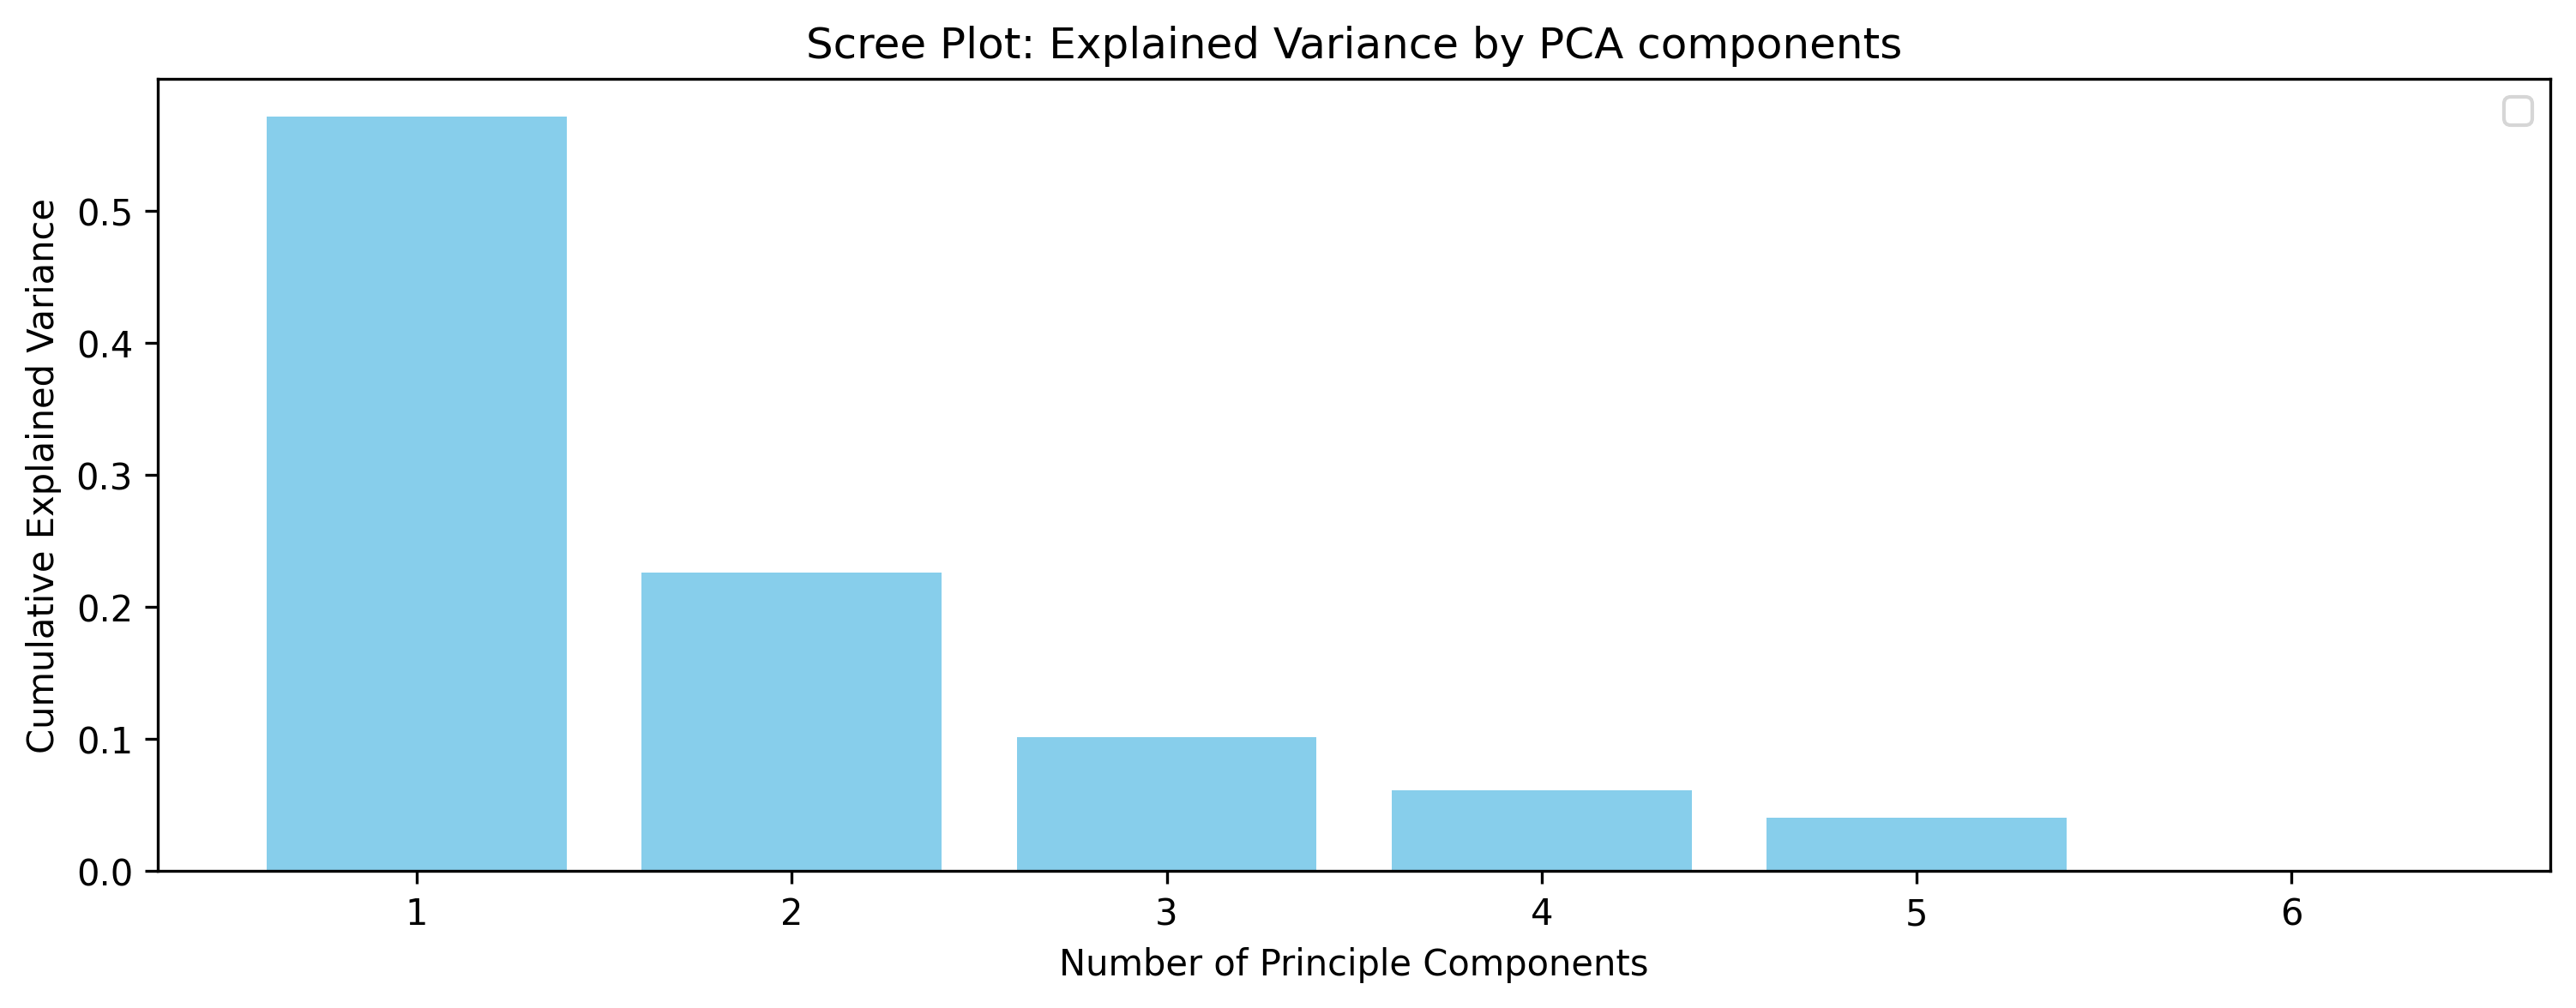

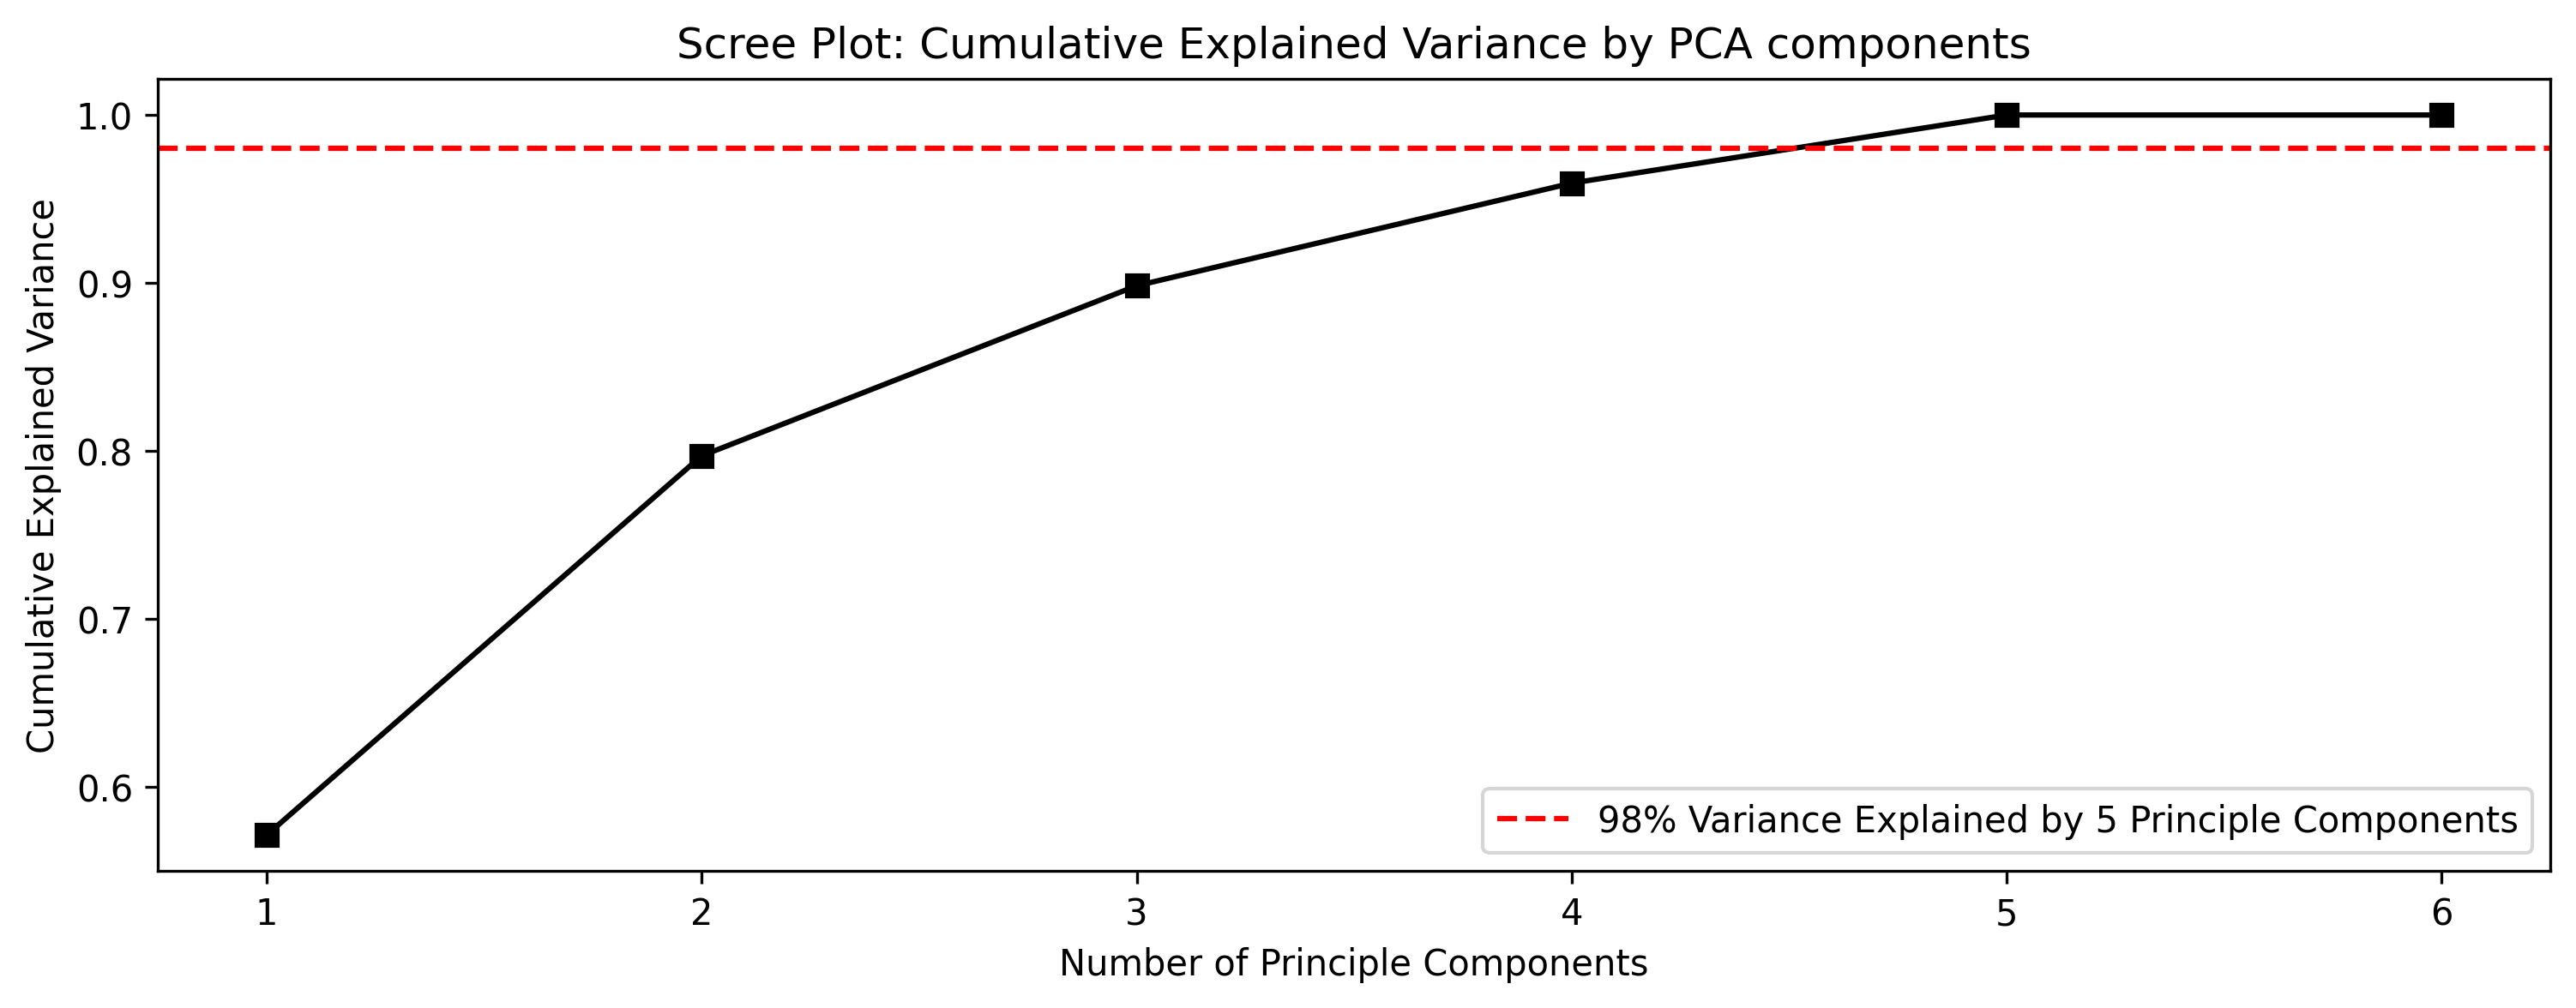

In [62]:
X = df.drop(["CustomerID"], axis = 1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA(random_state = 42)
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
x_axis = range(1, len(cumulative_variance) +1)

plt.figure(figsize = (12,4), dpi = 300)
plt.bar(x_axis, explained_variance, color = "skyblue")
plt.title("Scree Plot: Explained Variance by PCA components")
plt.xlabel("Number of Principle Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.show()

plt.figure(figsize = (12,4), dpi = 300)
plt.plot(x_axis, cumulative_variance, marker = 's', color = 'black')
plt.axhline(y = 0.98, linestyle = '--', color = 'red', label = "98% Variance Explained by 5 Principle Components")
plt.title("Scree Plot: Cumulative Explained Variance by PCA components")
plt.xlabel("Number of Principle Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.show()

Silhouette scores were computed and presented on a lineplot to validate the number of clusters/groups selection. 4 clusters were selected as being ideal, being the second highest in silhouette scores after 2 clusters.

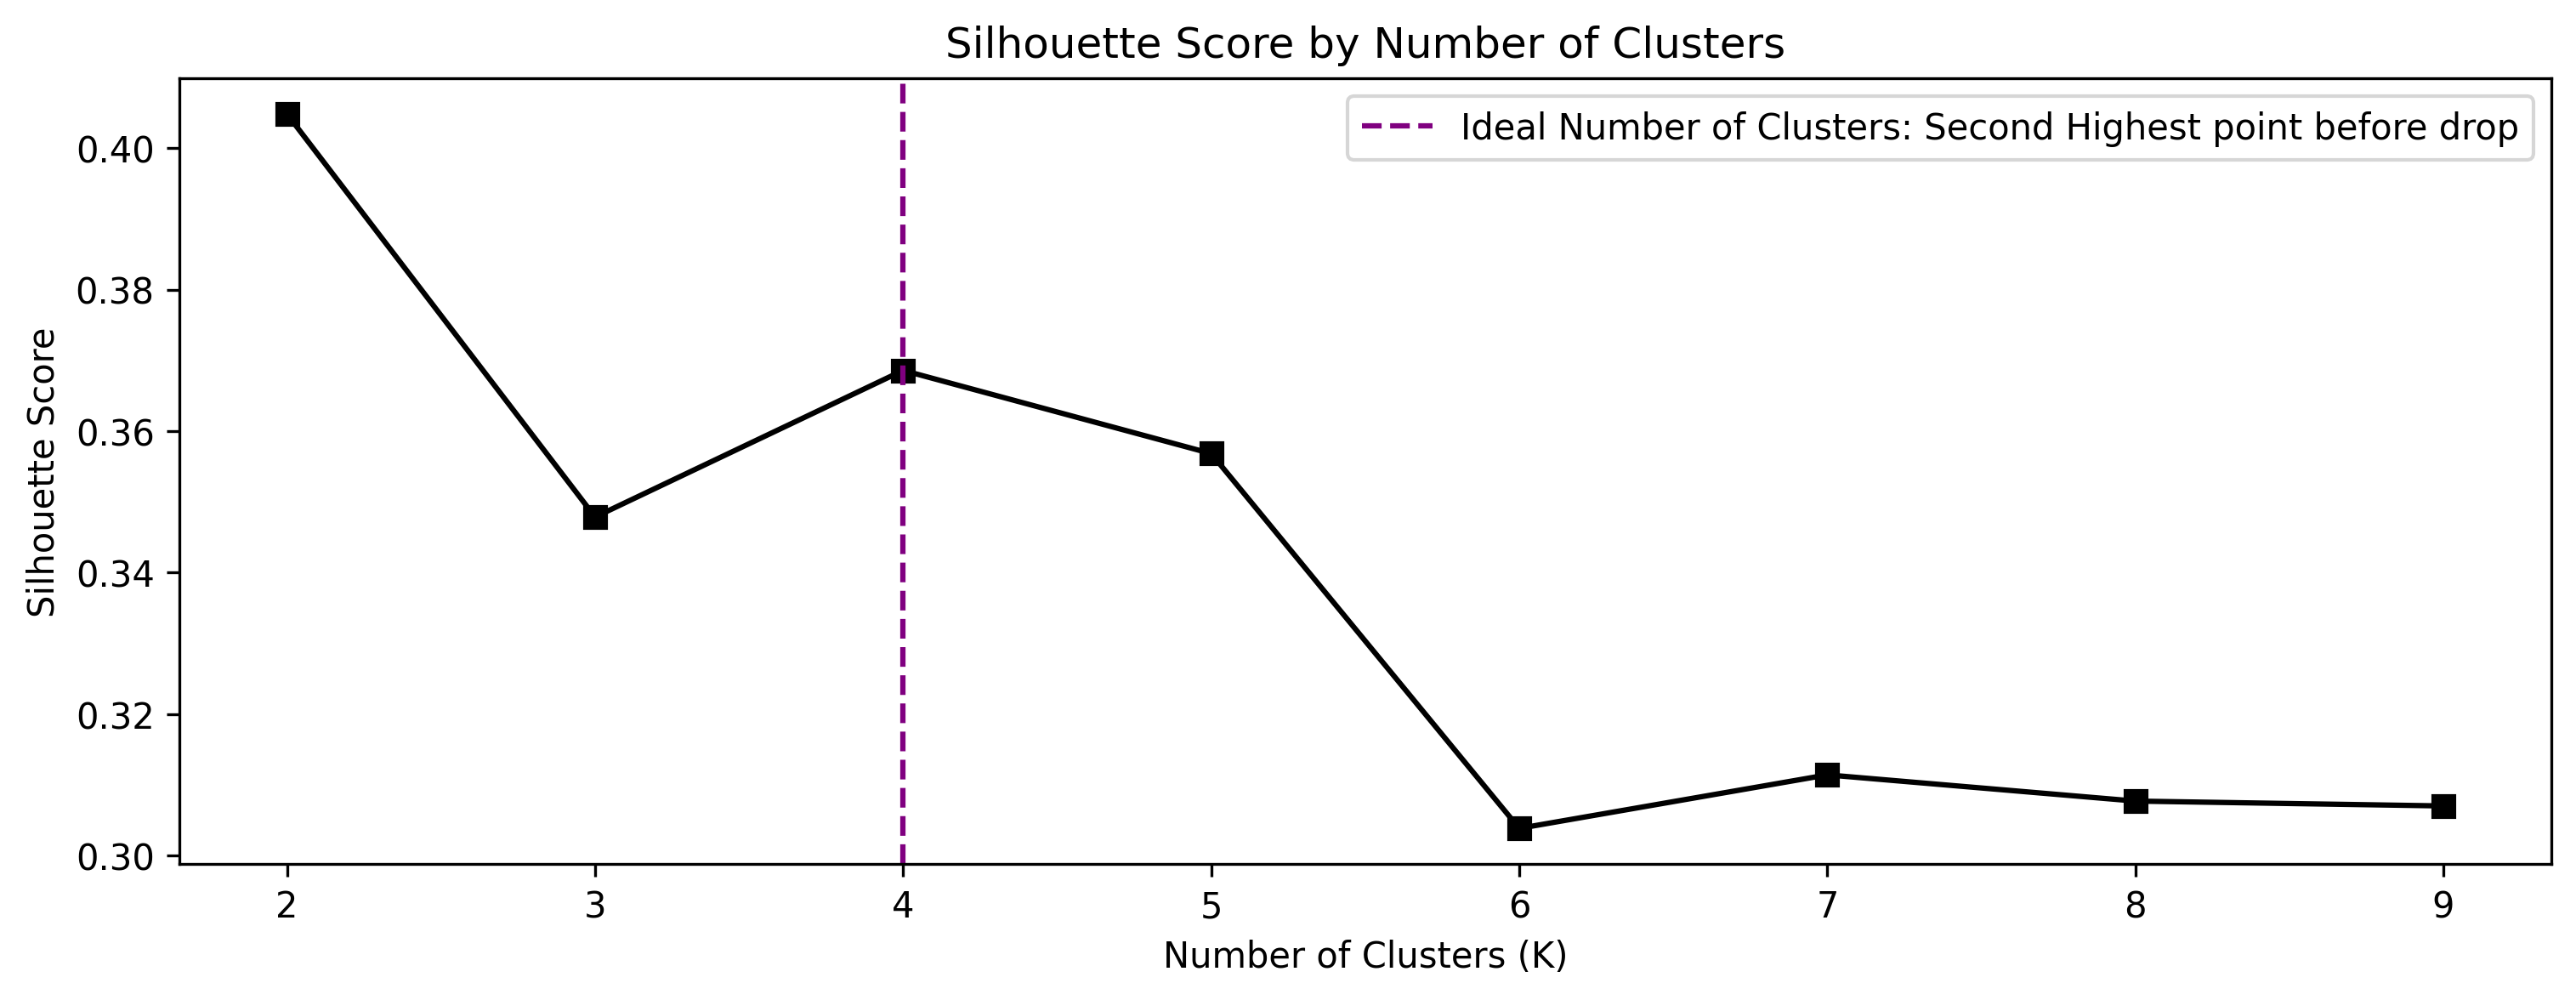

In [63]:
pca_components = 5

pca = PCA(n_components = pca_components, random_state = 42)

X_pca = pca.fit_transform(X_scaled)

k_range = range(2,10)

s_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    k_labels = kmeans.fit_predict(X_pca)
    sil_score = silhouette_score(X_pca, k_labels)
    s_scores.append(sil_score)

plt.figure(figsize = (12,4), dpi = 300)
plt.plot(k_range, s_scores, marker = 's', color = "black")
plt.axvline(x = 4, color = 'purple', linestyle = '--', label = "Ideal Number of Clusters: Second Highest point before drop")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.show()

The 5 principle components were fitted to the KMeans model with 4 clusters selected. After which, the model was stored as a joblib file, uploaded to AWS S3, and frozen to avoid version overwriting by rerunning the notebook.

To ensure the joblib file can effective be used to assign customer segmentation, it was downloaded from S3, and the principal component features were passed to the loaded model to assign labels to each customer.

To check whether the model genuinely found distinct pattern, the labels were highlighted on a scatter plot of PCA1 and PCA2, to visibly see the separations made by the model, and as presented below the model identified 4 distinct groups with clear separations.

KMeans model successfully saved to AWS S3

Model successfully loaded from AWS S3


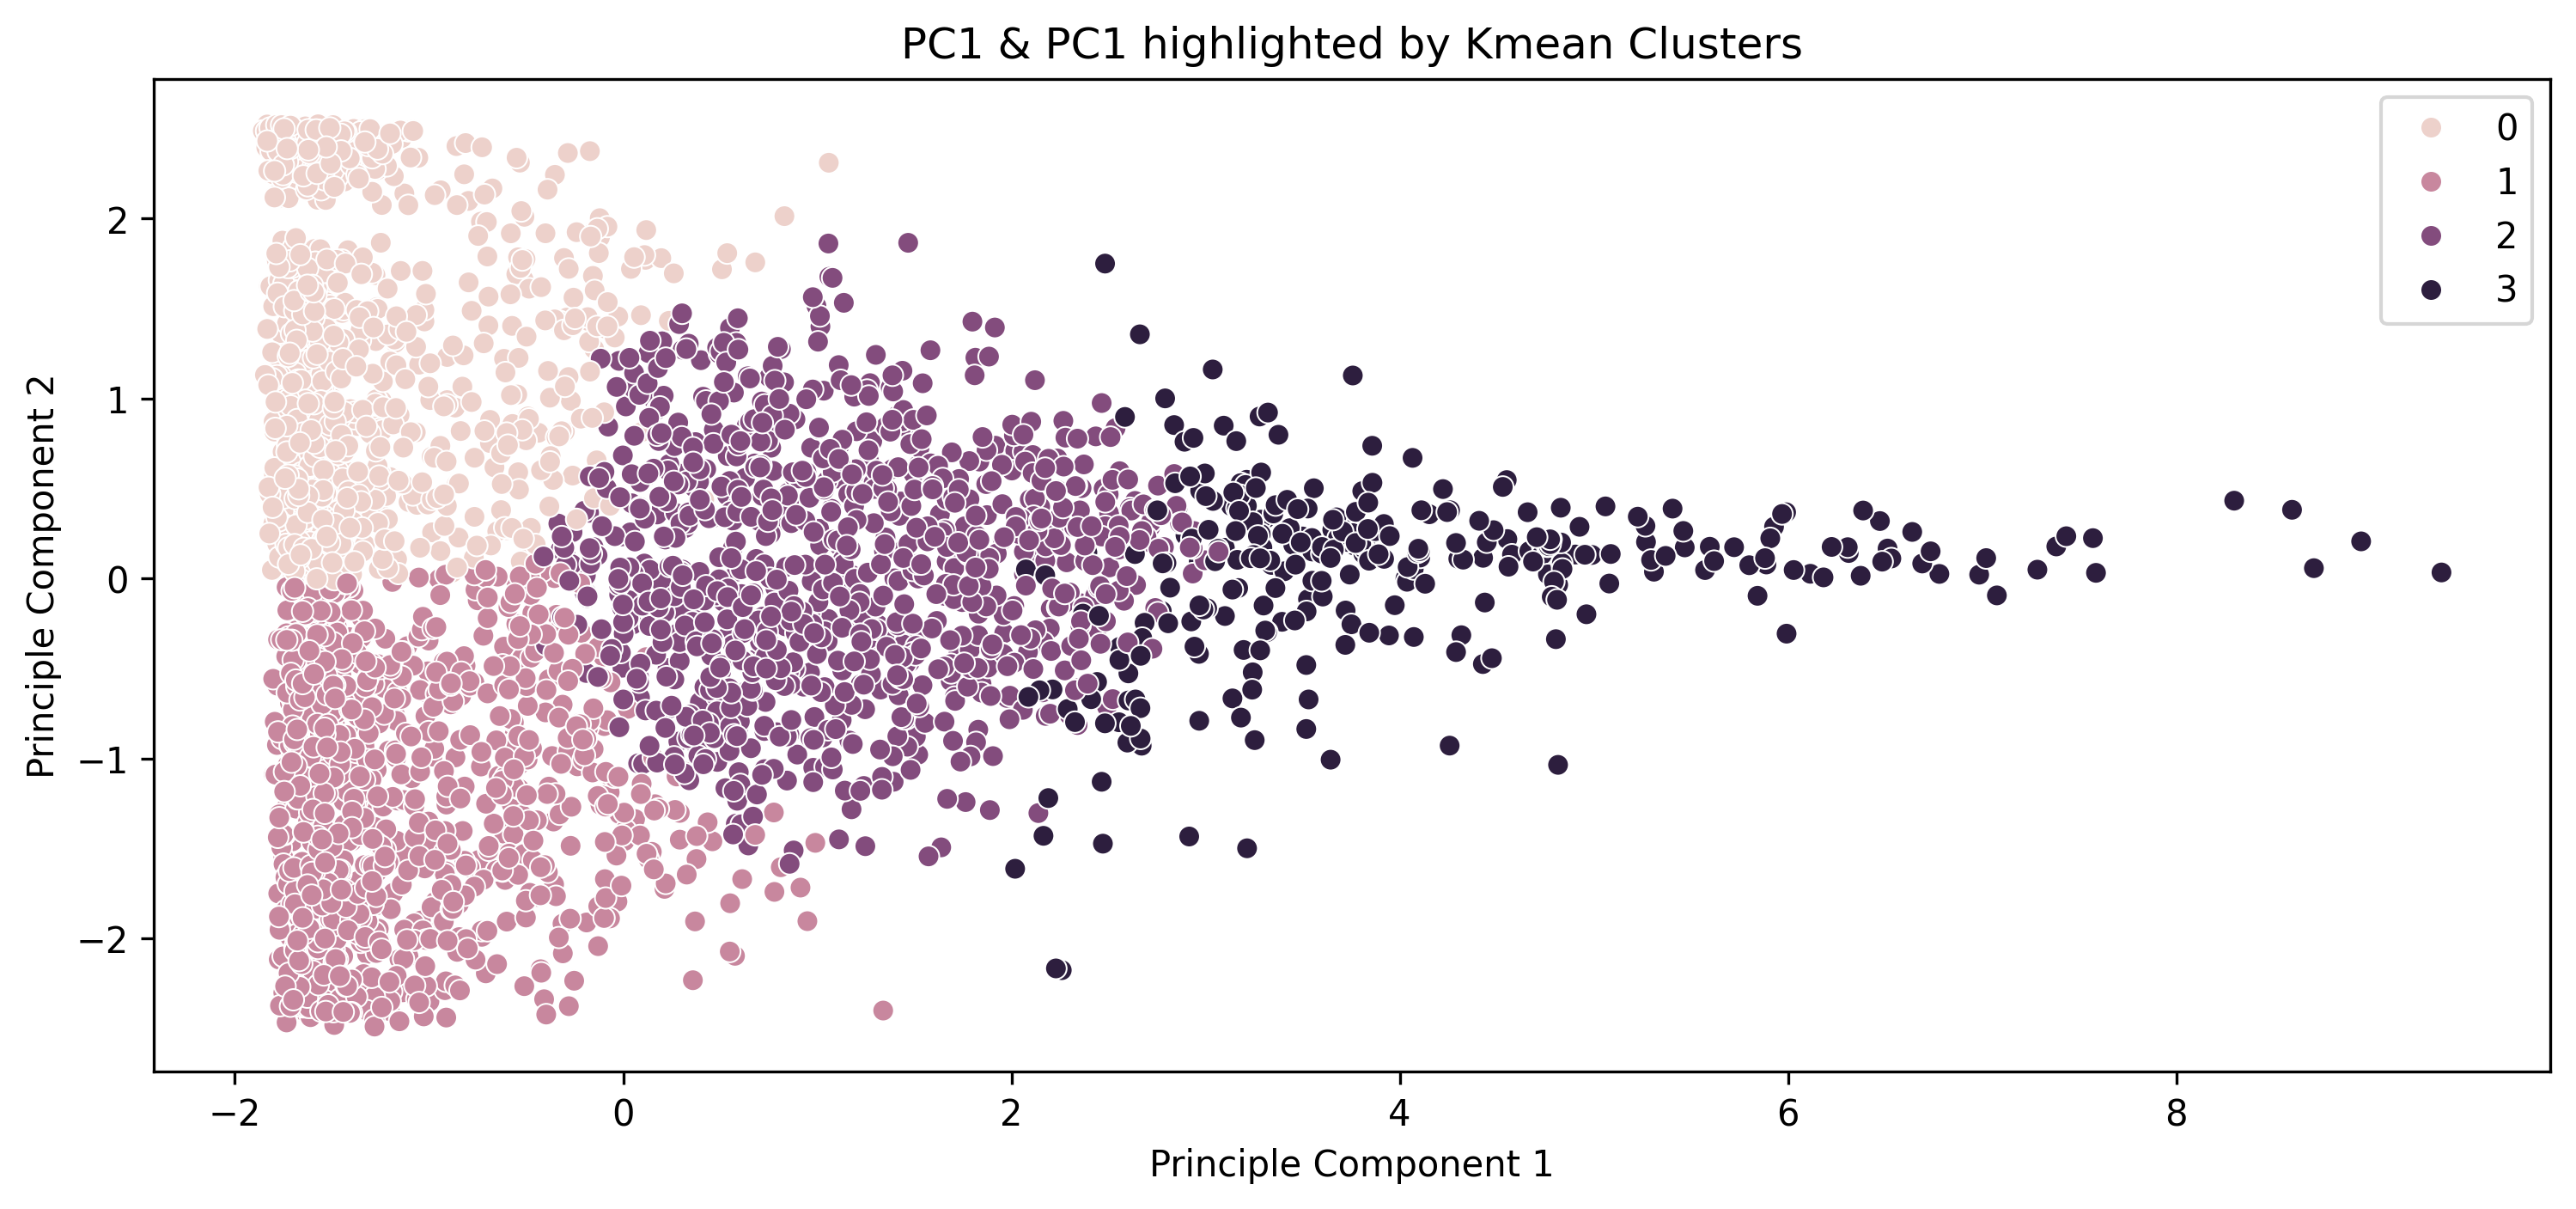

In [64]:
import joblib

ideal_clusters = 4

#After fitting model without outliers, and storing in drive, all data including outliers were fitted

pipeline_steps = [
   ('scaler', StandardScaler()),
   ('pca', PCA(n_components = pca_components, random_state = 42)),
   ('kmeans', KMeans(n_clusters = ideal_clusters, random_state = 42, n_init = 10))
]

pipeline = Pipeline(pipeline_steps)
pipeline.fit(X)

joblib.dump(pipeline, "kmeans_segmentation.joblib")
s3.upload_file("kmeans_segmentation.joblib", bucket_name, "predictive_models/kmeans_segmentation.joblib")
print(f'KMeans model successfully saved to AWS S3')

s3.download_file(bucket_name, "predictive_models/kmeans_segmentation.joblib", "kmeans_segmentation.joblib")

# For consistency, joblib file is pulled back to predict clusters
loaded_model = joblib.load("kmeans_segmentation.joblib")

print('\nModel successfully loaded from AWS S3')

k_labels = loaded_model.predict(X)

pc1 = X_pca[:,0]
pc2 = X_pca[:,1]

plt.figure(figsize = (12,5), dpi = 300)
sns.scatterplot(x = pc1, y = pc2, hue = k_labels)
plt.title("PC1 & PC1 highlighted by Kmean Clusters")
#plt.axhline(y = 2.4, color = "grey", linestyle = '--')
#plt.axvline(x = 0.3, color = "grey", linestyle = '--')
#plt.axvline(x = 5, color = "grey", linestyle = '--')
plt.xlabel("Principle Component 1")
plt.ylabel("Principle Component 2")
plt.show()

KMeans labels were assigned; creating the task to profile and translate the abstract labels into business meaning. This was done with the aid of visualisations; a heatmap showing actually median values being compared across labels, and box plots to review the spread of data points across labels.

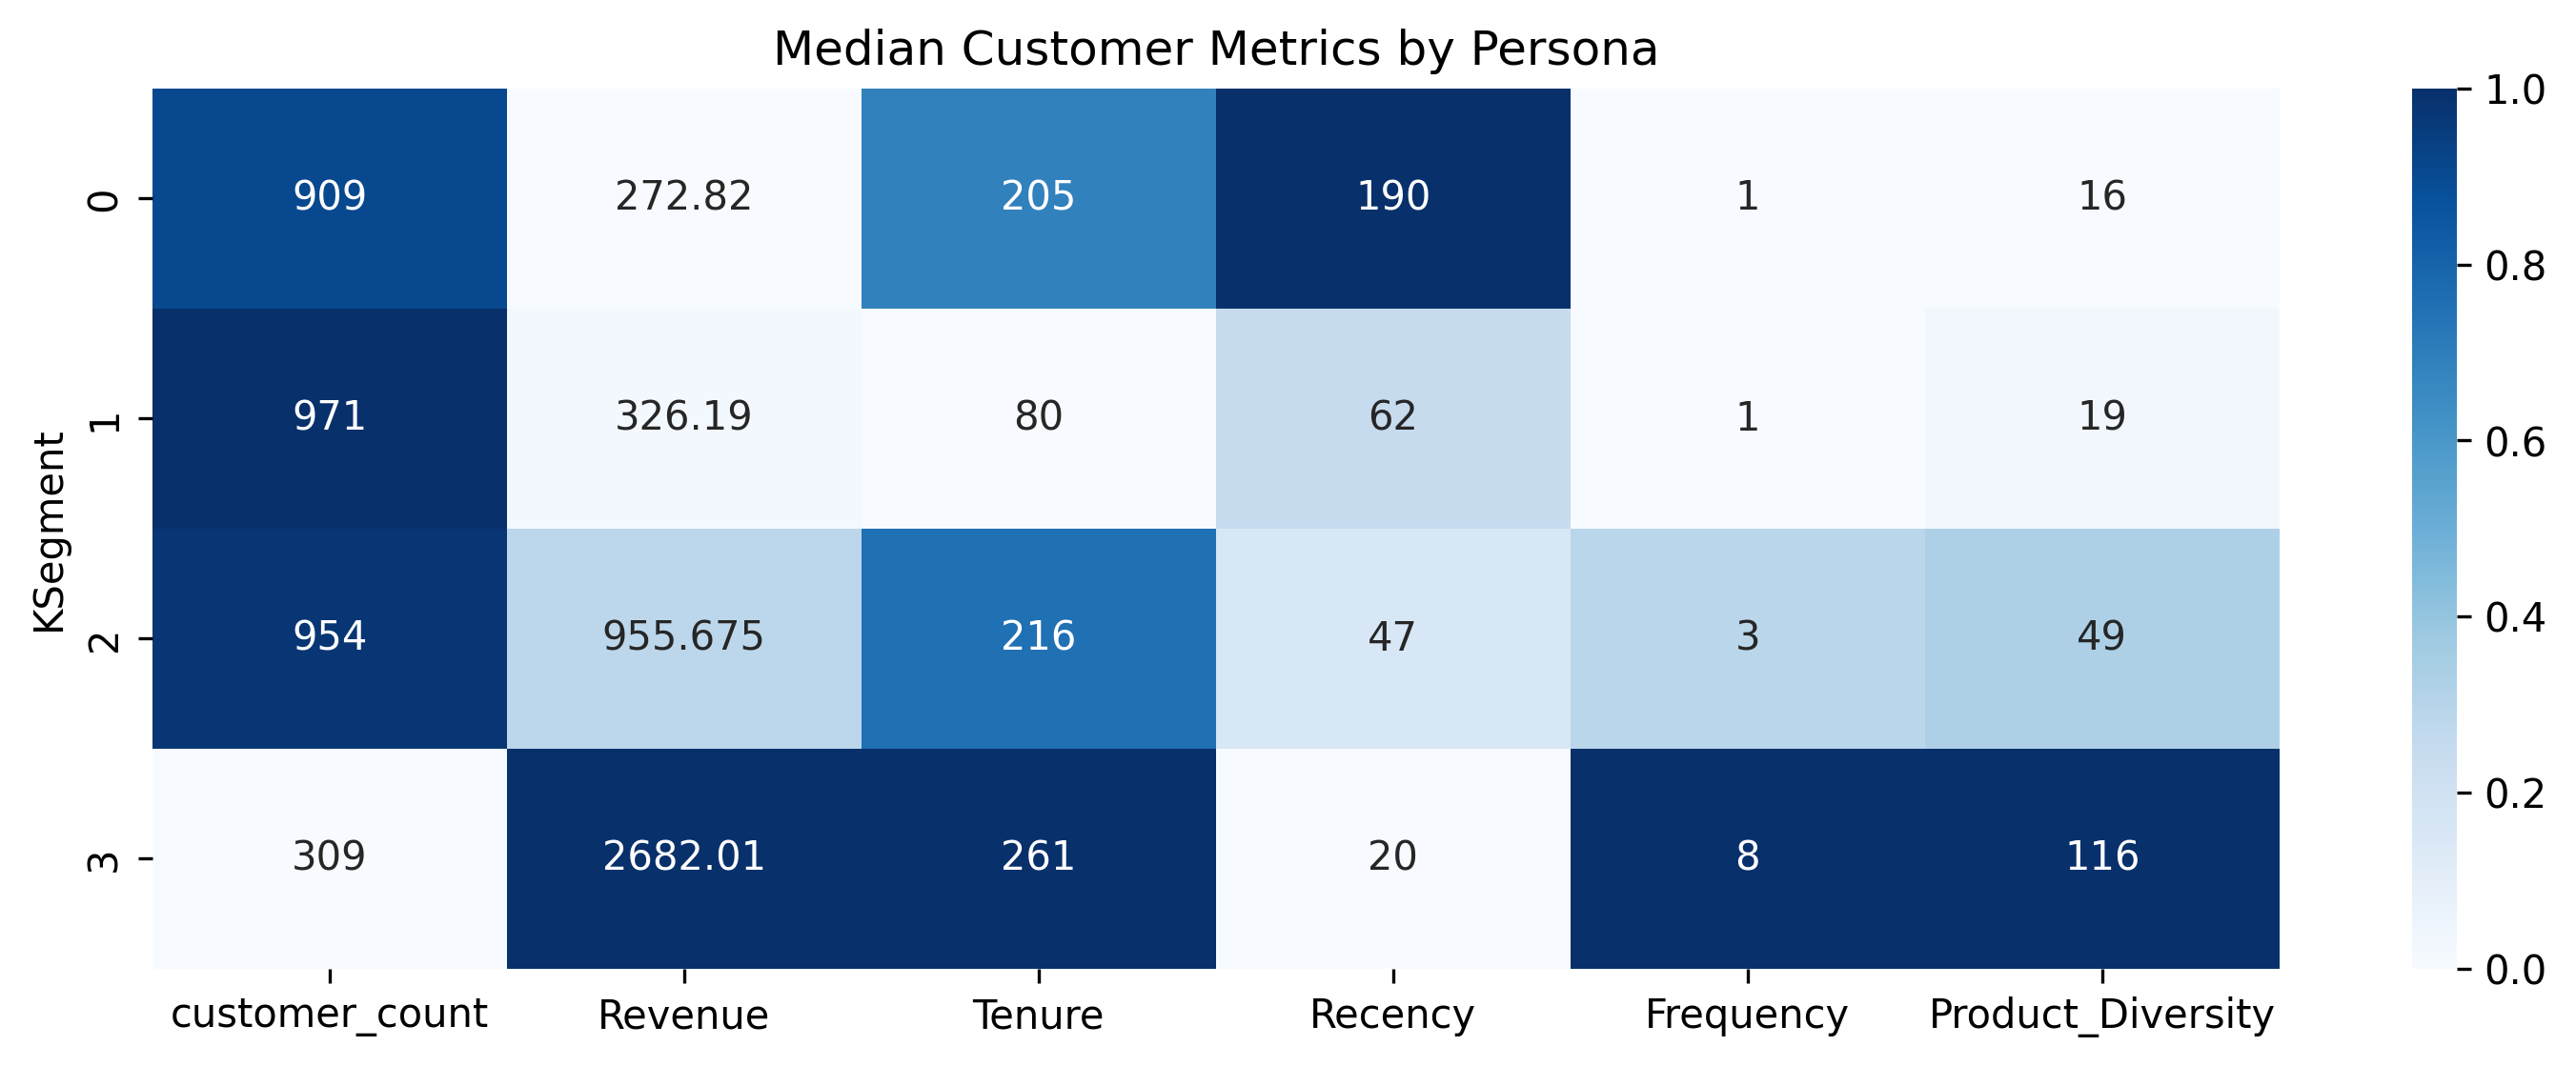

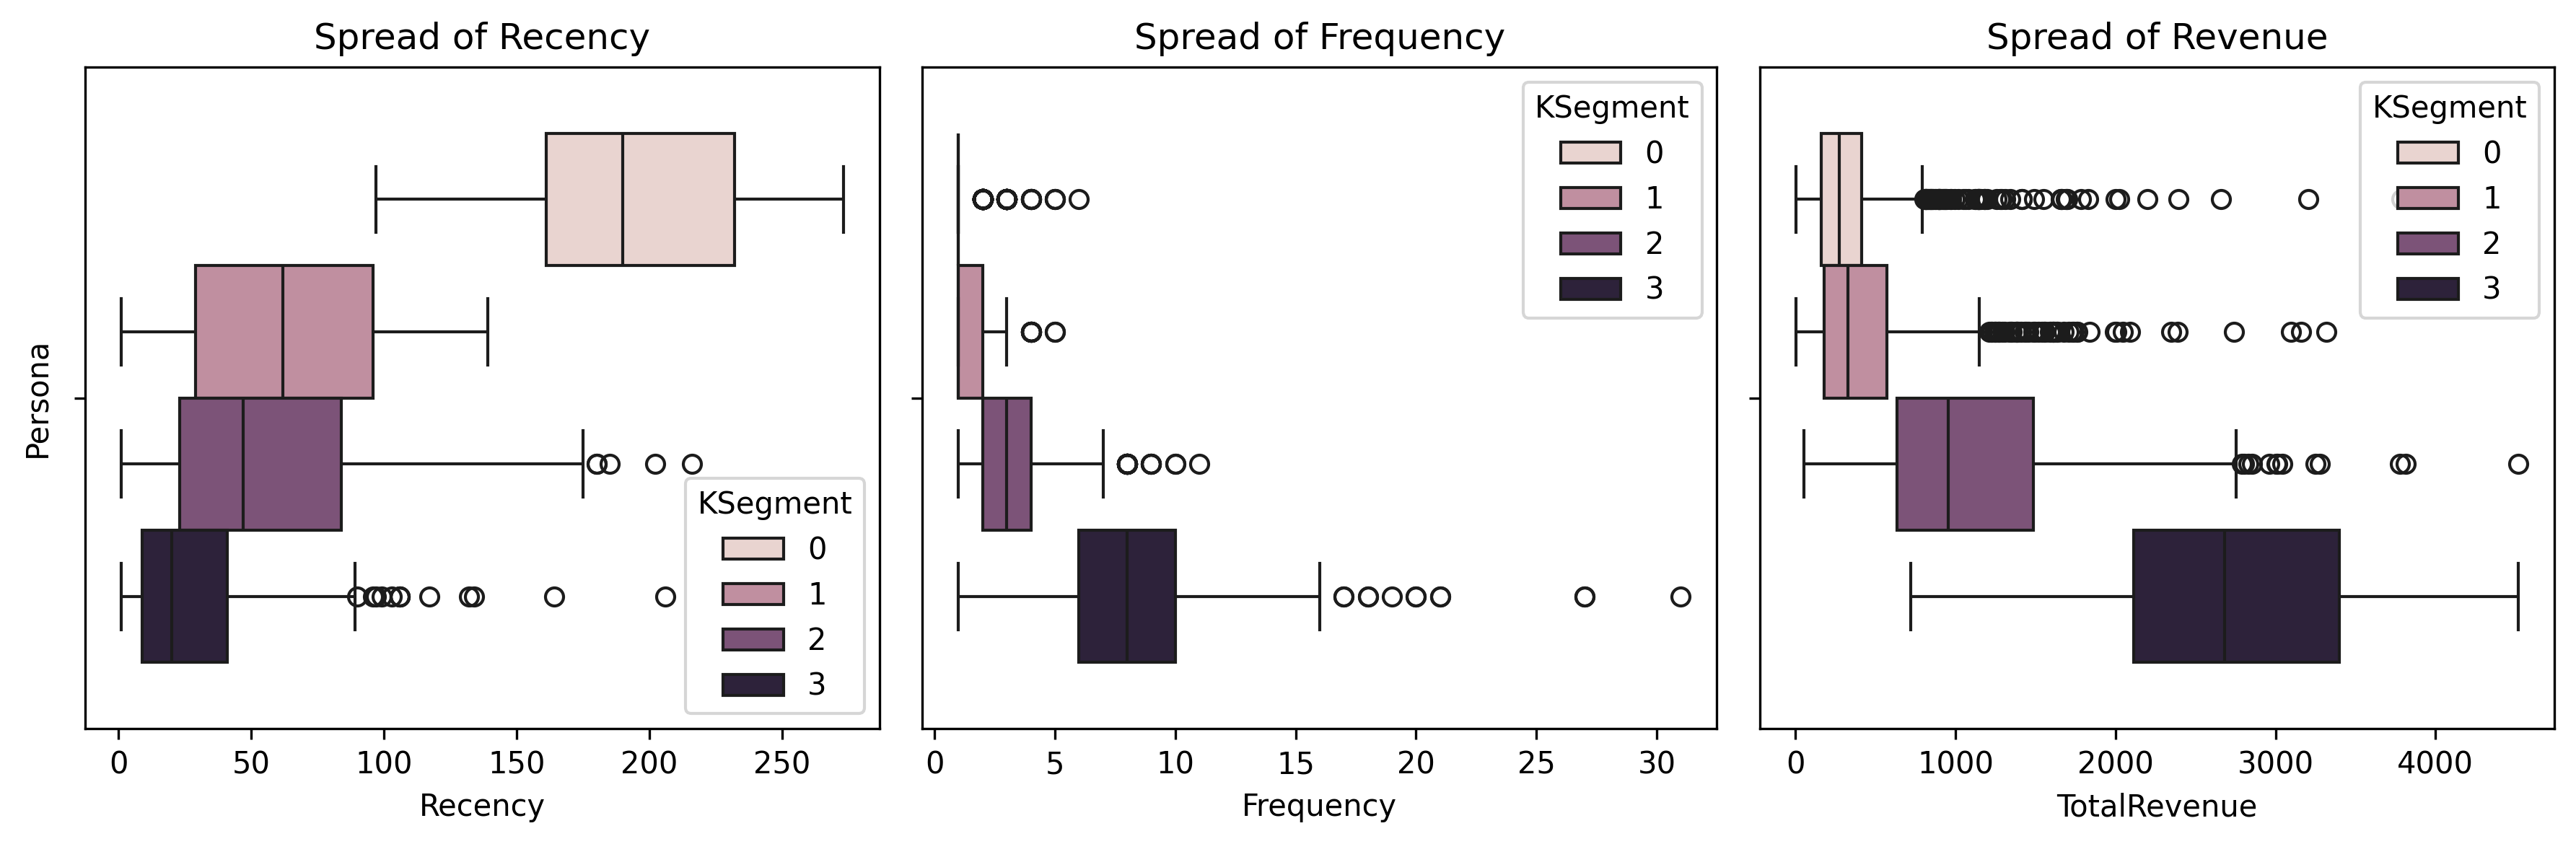

In [65]:
df["KSegment"] = k_labels

medians = df.groupby("KSegment").agg(
  customer_count = ("CustomerID", "count"),
  Revenue = ("TotalRevenue", "median"),
  Tenure = ("Tenure", "median"),
  Recency = ("Recency", "median"),
  Frequency = ("Frequency", "median"),
  Product_Diversity = ("ProductDiversity", "median"))

#medians = df.groupby("KSegment")[['Frequency', 'Recency', 'TotalRevenue', 'Tenure', 'ProductDiversity']].median()
medians_norm = (medians - medians.min())/(medians.max() - medians.min())

plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(data = medians_norm, annot = medians, fmt = 'g', cmap = 'Blues')
plt.title('Median Customer Metrics by Persona')
plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(1,3, dpi = 300, figsize = (12,4))
sns.boxplot(data = df, x = "Recency", hue = "KSegment", ax = ax1)
ax1.set_title("Spread of Recency")
ax1.set_ylabel("Persona")

sns.boxplot(data = df, x = "Frequency", hue = "KSegment", ax = ax2)
ax2.set_title("Spread of Frequency")
ax1.set_ylabel("Persona")

sns.boxplot(data = df, x = "TotalRevenue", hue = "KSegment", ax = ax3)
ax3.set_title("Spread of Revenue")
ax1.set_ylabel("Persona")

plt.tight_layout()
plt.show()

Describing and distinguishing cluster labels
- `Cluster 0` : These customers present the least shopping frequency, least median product diversity, and the lowest median revenue. These client are among the oldest in tenure terms, and coupled with their high recency are classified as `Lost and Inactive`

- `Cluster 1`: This segment exhibits similar characteristics with cluster 1, with the same median frequency, and small variation in product diversity. However, the only significant differences between the two clusters is the median recency (63 vs 190). Overall, this cluster has the lowest tenure across all cluster, however the other metric point that these clients are more likely downgrade to cluster 0 than upgrade, and are classified as `Low Engagement & at Risk`

- `Cluster 2`: This segment has an older median tenure compared to Cluster 0 and 1, and even better frequency, and product diversity medians, with almost 3 times the median revenue of cluster 1, and is classified on their high revenue, tenure, and high product diversity as `Loyal Performers`.

- `Cluster 3` : This segment presents the best performance across all metrics, and cominh from the smallest group of customers, are classified as `High-Value Elite.`


Reviewing Similarities and Differences between the `lost & Inactive` and `Low Engagement & at Risk` Segments
- As earlier mentioned, the only metric distinguishing the above groups is the tenure, whole as revenue and frequency appear almost indifferent, as Recency increases the Low-Engagement group is expected to downgrade to the Lost & Inactive segment


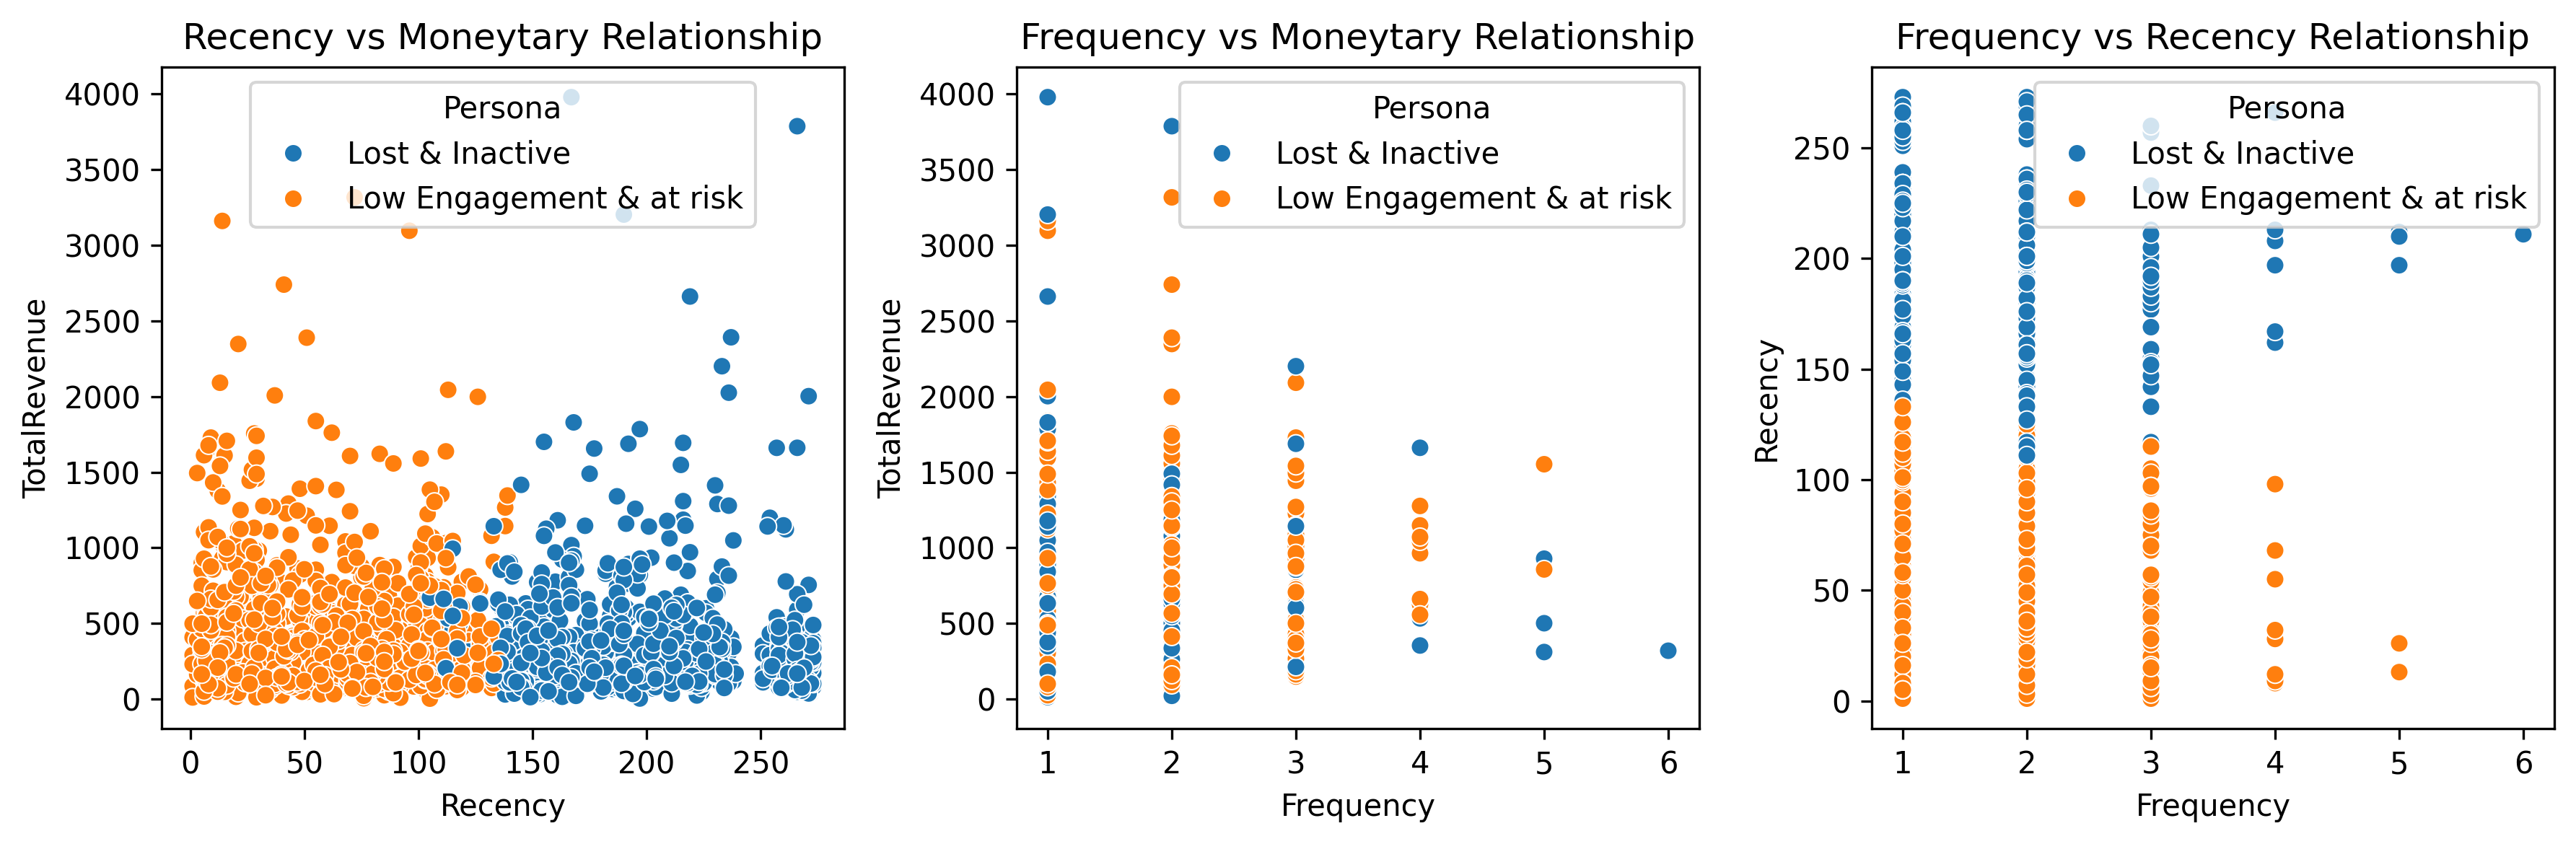



Reviewing Similarities and Differences between the `Loyal Performers` and `High-Value Elite` Segments
- One the other hand, the Loyal Performers, and the High-Value Elite classes, are cluster around the same Recency ranges, with substantial difference in Revenue, and Frequency spread


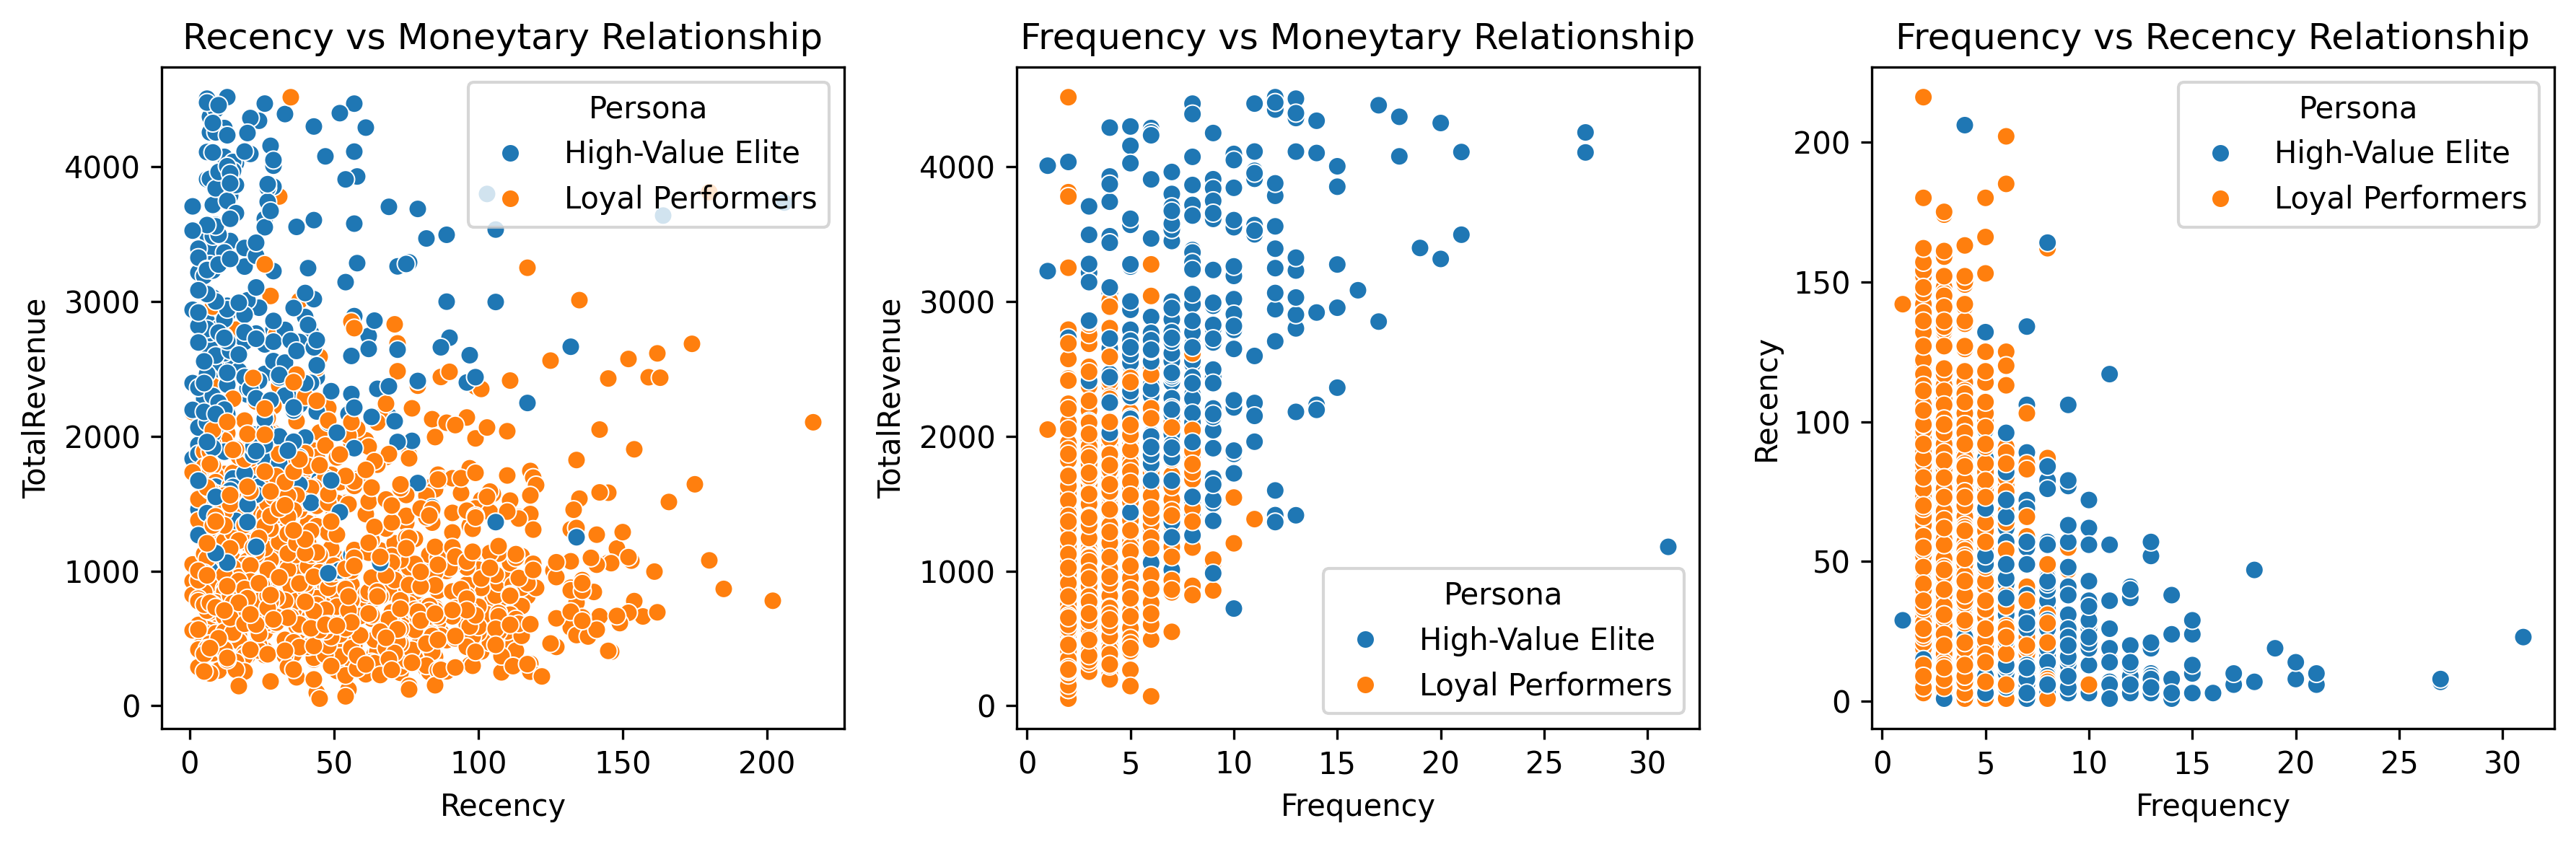

In [66]:
segment_map = {
0: "Lost & Inactive",
1: "Low Engagement & at risk",
2: "Loyal Performers",
3: "High-Value Elite"
}

df["Persona"] = df["KSegment"].map(segment_map)

# Displaying Segments 0 and 1
print("\nReviewing Similarities and Differences between the `lost & Inactive` and `Low Engagement & at Risk` Segments")
print("- As earlier mentioned, the only metric distinguishing the above groups is the tenure, whole as revenue and frequency appear almost indifferent, as Recency increases the Low-Engagement group is expected to downgrade to the Lost & Inactive segment")

fig, (ax1, ax2, ax3) = plt.subplots(1,3, dpi = 300, figsize = (12,4))
sns.scatterplot(data = df.query('KSegment < 2'), x = "Recency", y = "TotalRevenue", hue = "Persona", ax = ax1)
ax1.set_title("Recency vs Moneytary Relationship")
ax1.set_ylabel("TotalRevenue")

sns.scatterplot(data = df.query('KSegment < 2'), x = "Frequency", y = "TotalRevenue", hue = "Persona", ax = ax2)
ax2.set_title("Frequency vs Moneytary Relationship")
ax2.set_ylabel("TotalRevenue")

sns.scatterplot(data = df.query('KSegment < 2'), x = "Frequency", y = "Recency" , hue = "Persona", ax = ax3)
ax3.set_title("Frequency vs Recency Relationship")
ax3.set_ylabel("Recency")

plt.tight_layout()
plt.show()

print()

# Displaying segments 2 and 3
print("\nReviewing Similarities and Differences between the `Loyal Performers` and `High-Value Elite` Segments")
print("- One the other hand, the Loyal Performers, and the High-Value Elite classes, are cluster around the same Recency ranges, with substantial difference in Revenue, and Frequency spread")
fig, (ax1, ax2, ax3) = plt.subplots(1,3, dpi = 300, figsize = (12,4))
sns.scatterplot(data = df.query('KSegment >= 2'), x = "Recency", y = "TotalRevenue", hue = "Persona", ax = ax1)
ax1.set_title("Recency vs Moneytary Relationship")
ax1.set_ylabel("TotalRevenue")

sns.scatterplot(data = df.query('KSegment >= 2'), x = "Frequency", y = "TotalRevenue", hue = "Persona", ax = ax2)
ax2.set_title("Frequency vs Moneytary Relationship")
ax2.set_ylabel("TotalRevenue")

sns.scatterplot(data = df.query('KSegment >= 2'), x = "Frequency", y = "Recency" , hue = "Persona", ax = ax3)
ax3.set_title("Frequency vs Recency Relationship")
ax3.set_ylabel("Recency")

plt.tight_layout()
plt.show()

Reference to the graph below, it was observed that the `High-Value Elite`, `Loyal Performers`, and the `Lost & Inactive` segments fall roughly beyond a 140 days tenure, which is roughly the ceiling of the `Low-Engagement` segment.

However, `ObservedLifeSpan` roughly seats around above 100days for the `Loyal Performers` and the `High-Value Elite` segments, suggesting that these are customers who from their first contact with the business exceeded a 100 day relationship, which is the ceiling that the `Lost & Inactive` clients bearly cross before they churn, and is the mark the `Low-Engagement` need to cross to upgrade to `Loyal Performers` in ObservedLifeSpan terms.

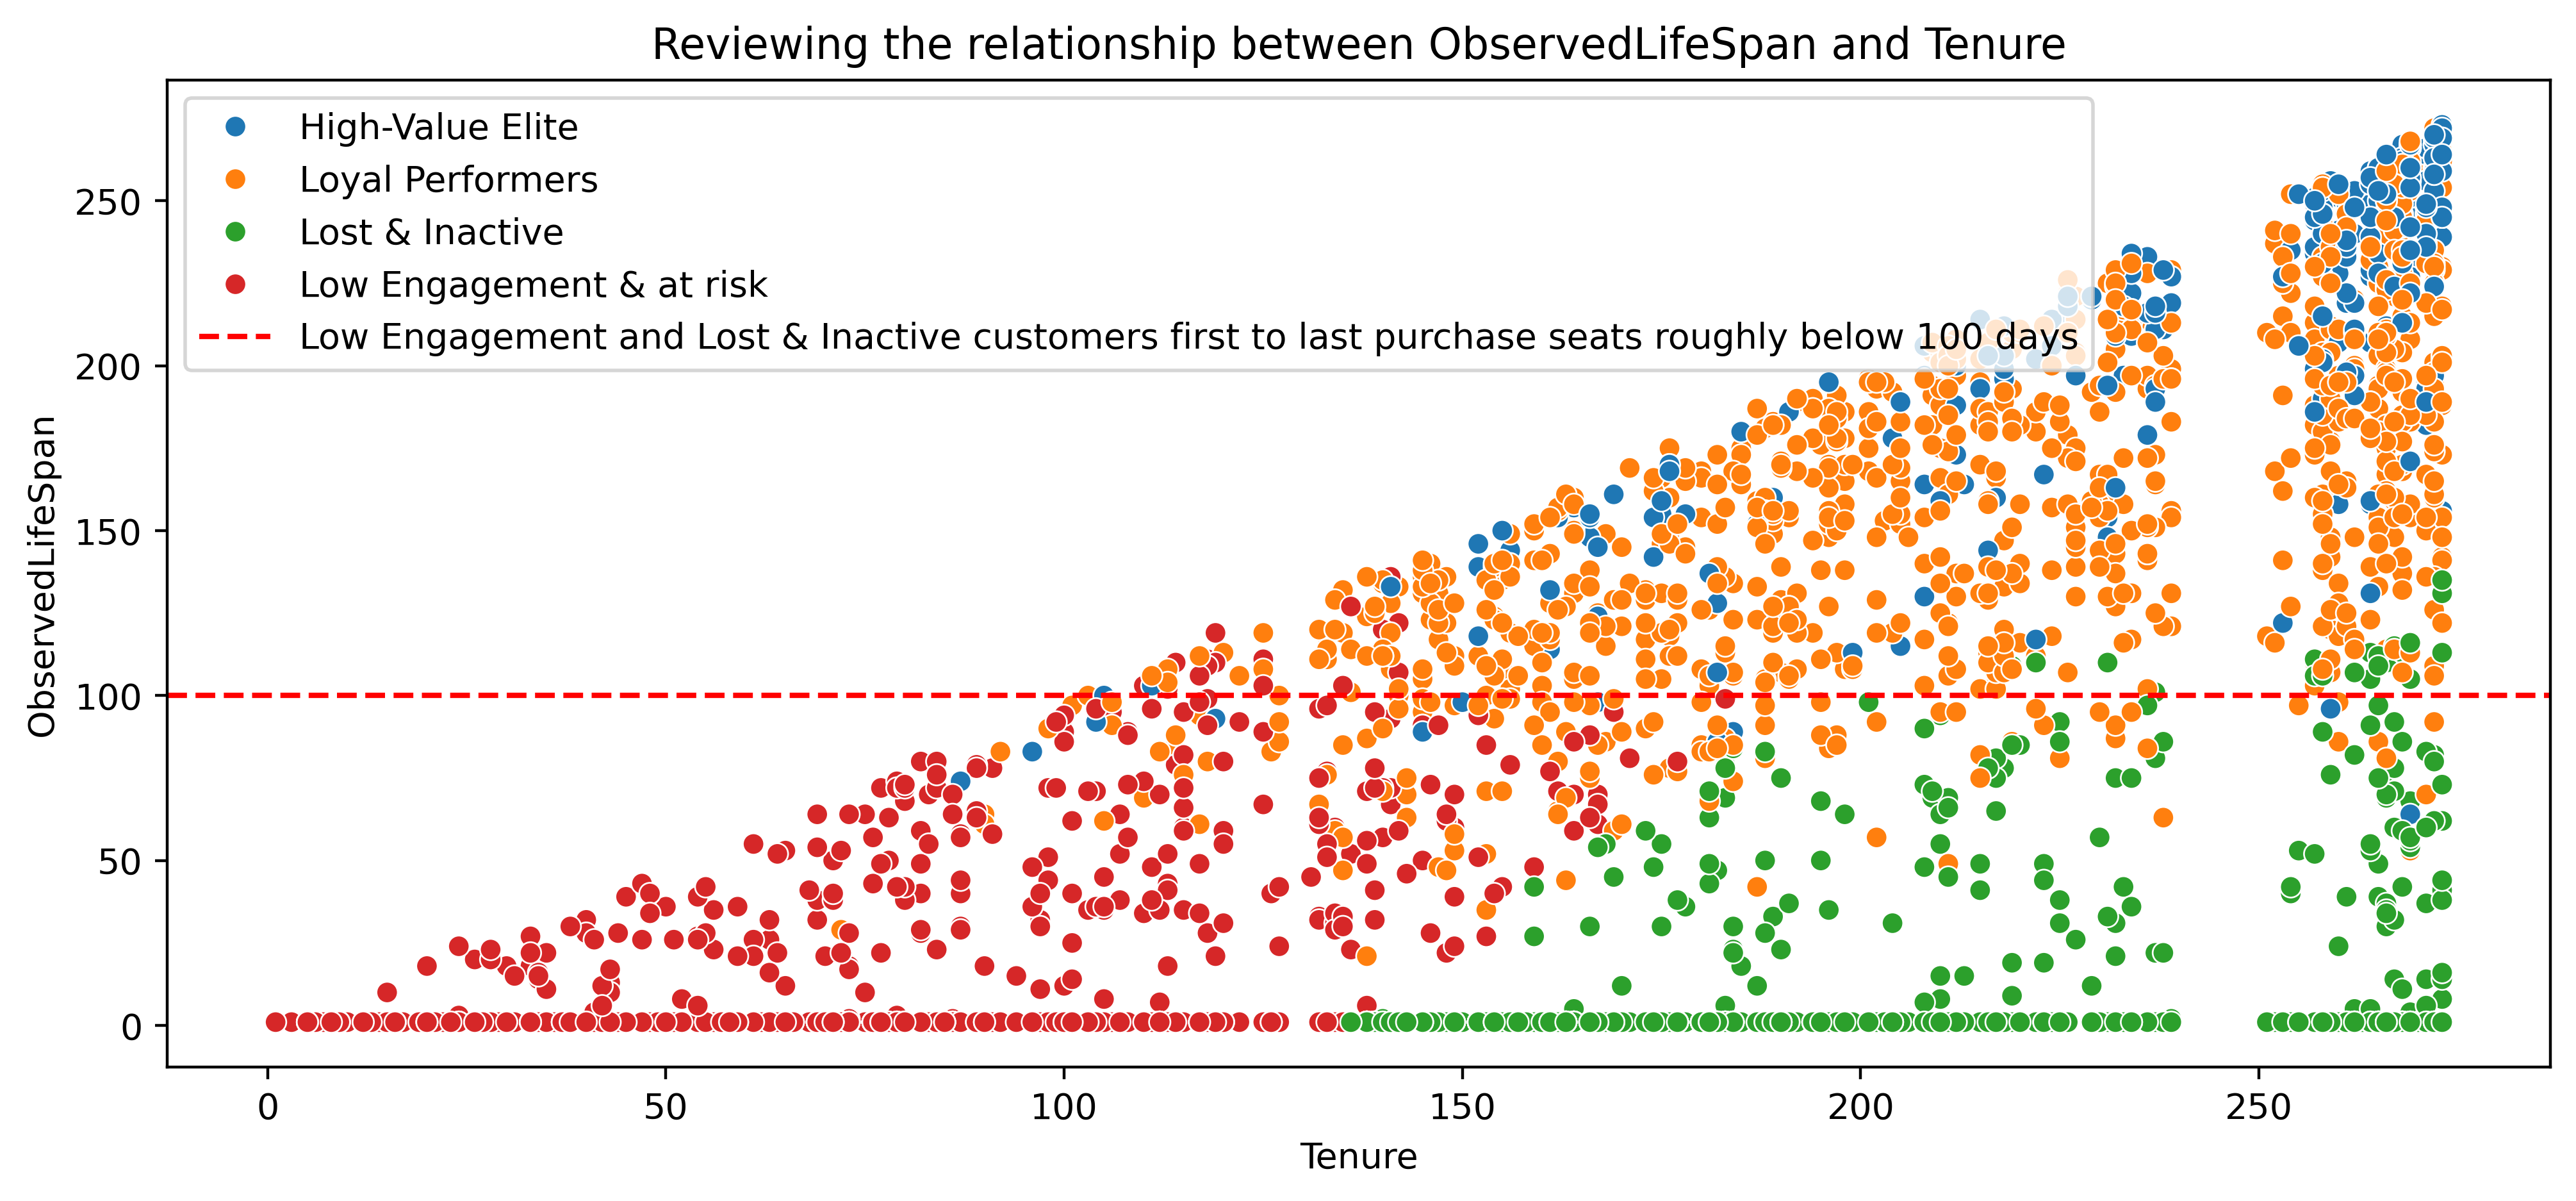

In [67]:
plt.figure(figsize = (12, 5), dpi = 400)
sns.scatterplot(data = df, x = "Tenure", y = "ObservedLifeSpan" , hue = "Persona")
plt.title("Reviewing the relationship between ObservedLifeSpan and Tenure")
plt.axhline(100, linestyle = '--' , color = 'red', label = "Low Engagement and Lost & Inactive customers first to last purchase seats roughly below 100 days")
plt.legend()
plt.show()

The line and bar graph below links the customer segments to the customers' cohort month. As observed ealier, almost zero clients, with few exceptions, were assigned to the `High-Value Elite`, `Loyal Performers`, and `Lost & Inactive` segments since the month of `May`, which is about 120 days to August end date. On the other end, almost all new customers registered since may being classed as `Low-Engagement & at Risk`. Nevertheless, a notable downtrend was observed in the number new customers, declining for 8 consecutive months.

Drawing attention to the heatmap,

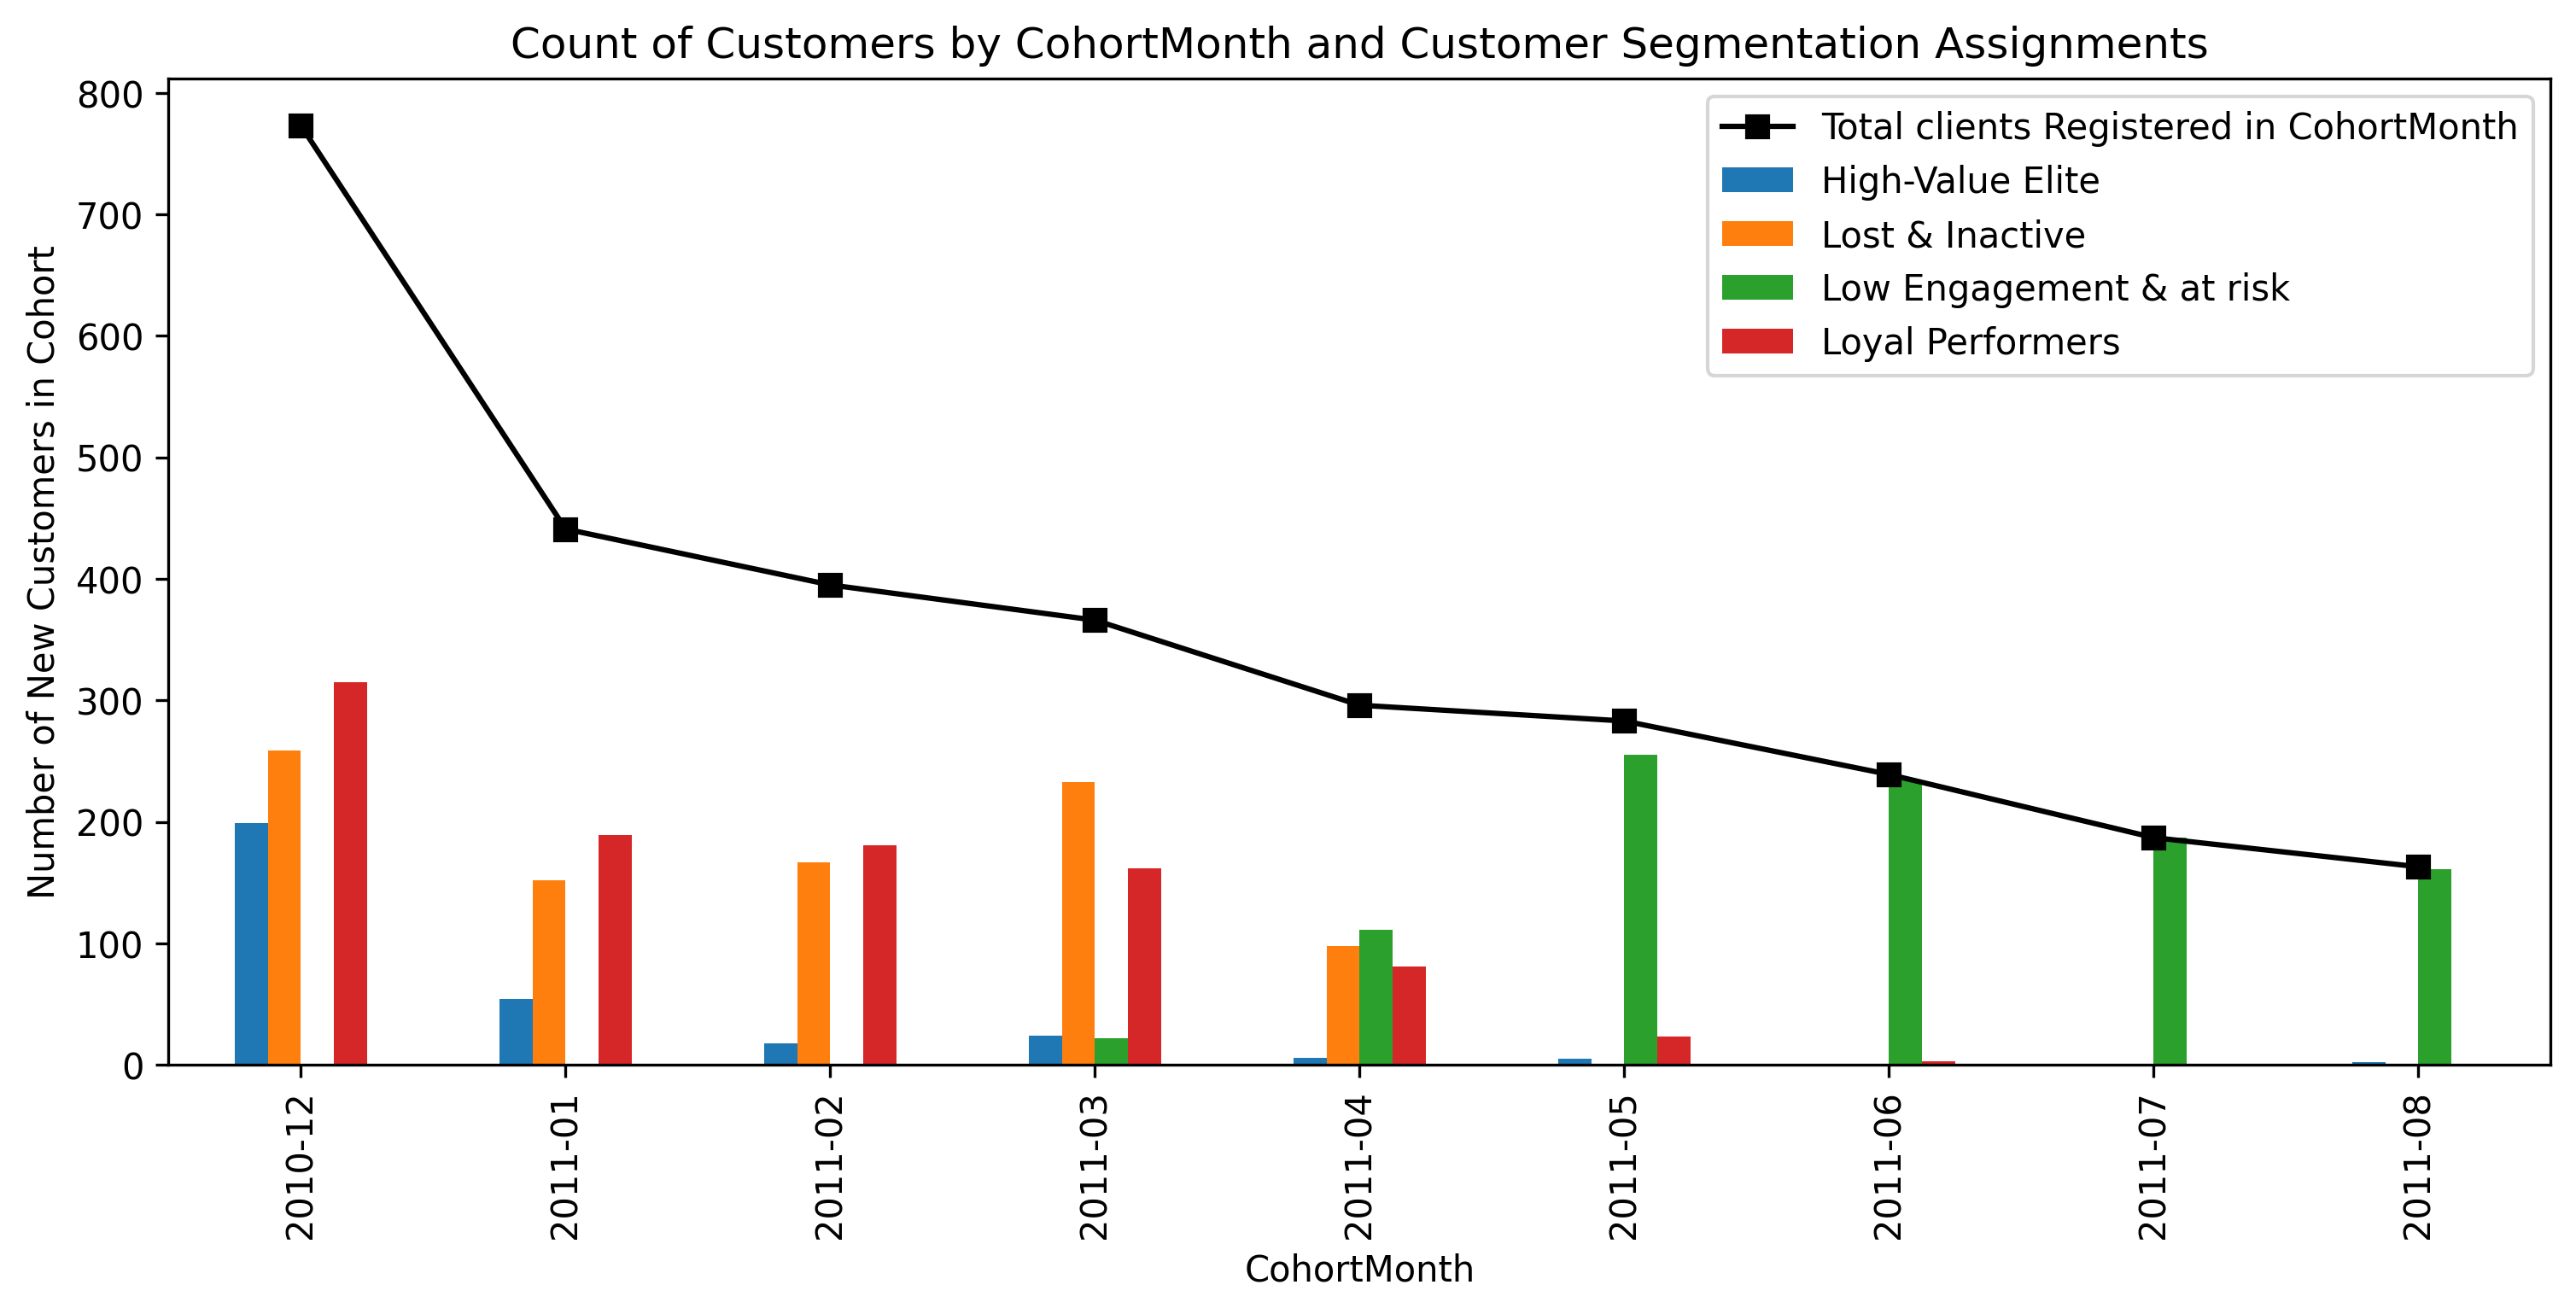

In [69]:
cohort_df = df.merge(cohort_df, on = "CustomerID", how = 'left')

total_clients = cohort_df["CohortMonth"].value_counts().reset_index()
total_clients["CohortMonth"] = total_clients["CohortMonth"].astype("str")

crosstab_persona  = pd.crosstab(cohort_df["CohortMonth"], cohort_df["Persona"])

crosstab_norm = (crosstab_persona - crosstab_persona.min())/(crosstab_persona.max() - crosstab_persona.min())

fig, ax = plt.subplots(1,1,figsize = (12,5), dpi = 300)
crosstab_persona.plot(kind = "bar", ax = ax)
ax.plot(total_clients["CohortMonth"], total_clients['count'], marker = 's', color = "black", label = "Total clients Registered in CohortMonth")
#sns.heatmap(data = crosstab_norm,annot = crosstab_persona, ax = ax, fmt = 'g', cmap = "Blues")
ax.set_ylabel("Number of New Customers in Cohort")

plt.title("Count of Customers by CohortMonth and Customer Segmentation Assignments")
plt.legend()
plt.show()

With the objective to get a picture of the monthly proportions of segment `turnout` and `customer spend`, heatmaps showing customer turnout, and revenue by segment, was plotted as displayed below.

- `Loyal performers` presented the strongest monthly purchase turnout. This cohort, currently holding 954 customers, presents a monthly customer turnout currently ranging between `268 - 392` customers `(at least 28% of the cohort has been spending in  month)` , registering the highest monthly revenue of all cohorts, ranging between `$96,741.30 and $139,186`.

- On the other hand, `High-Value Elite` customers rank second consistently in monthly spend, with revenues currently ranging between `$67,641 and `112,277`, from a segment of only 309 customer with the highest segment monthly turnout rate, ranging between `177 and 218`

- The `Lost & Inactive` and the `Low-Engagement` segments, as established ealier, exhibit the same customer behaviour, varying on in tenure. These segments, collectively capture the behaviour of new customers, and collectively presenting a monthly turnout currently ranging between `177 and 302` customers, having registered revenues ranging between `$60,561.90 and $101,203`

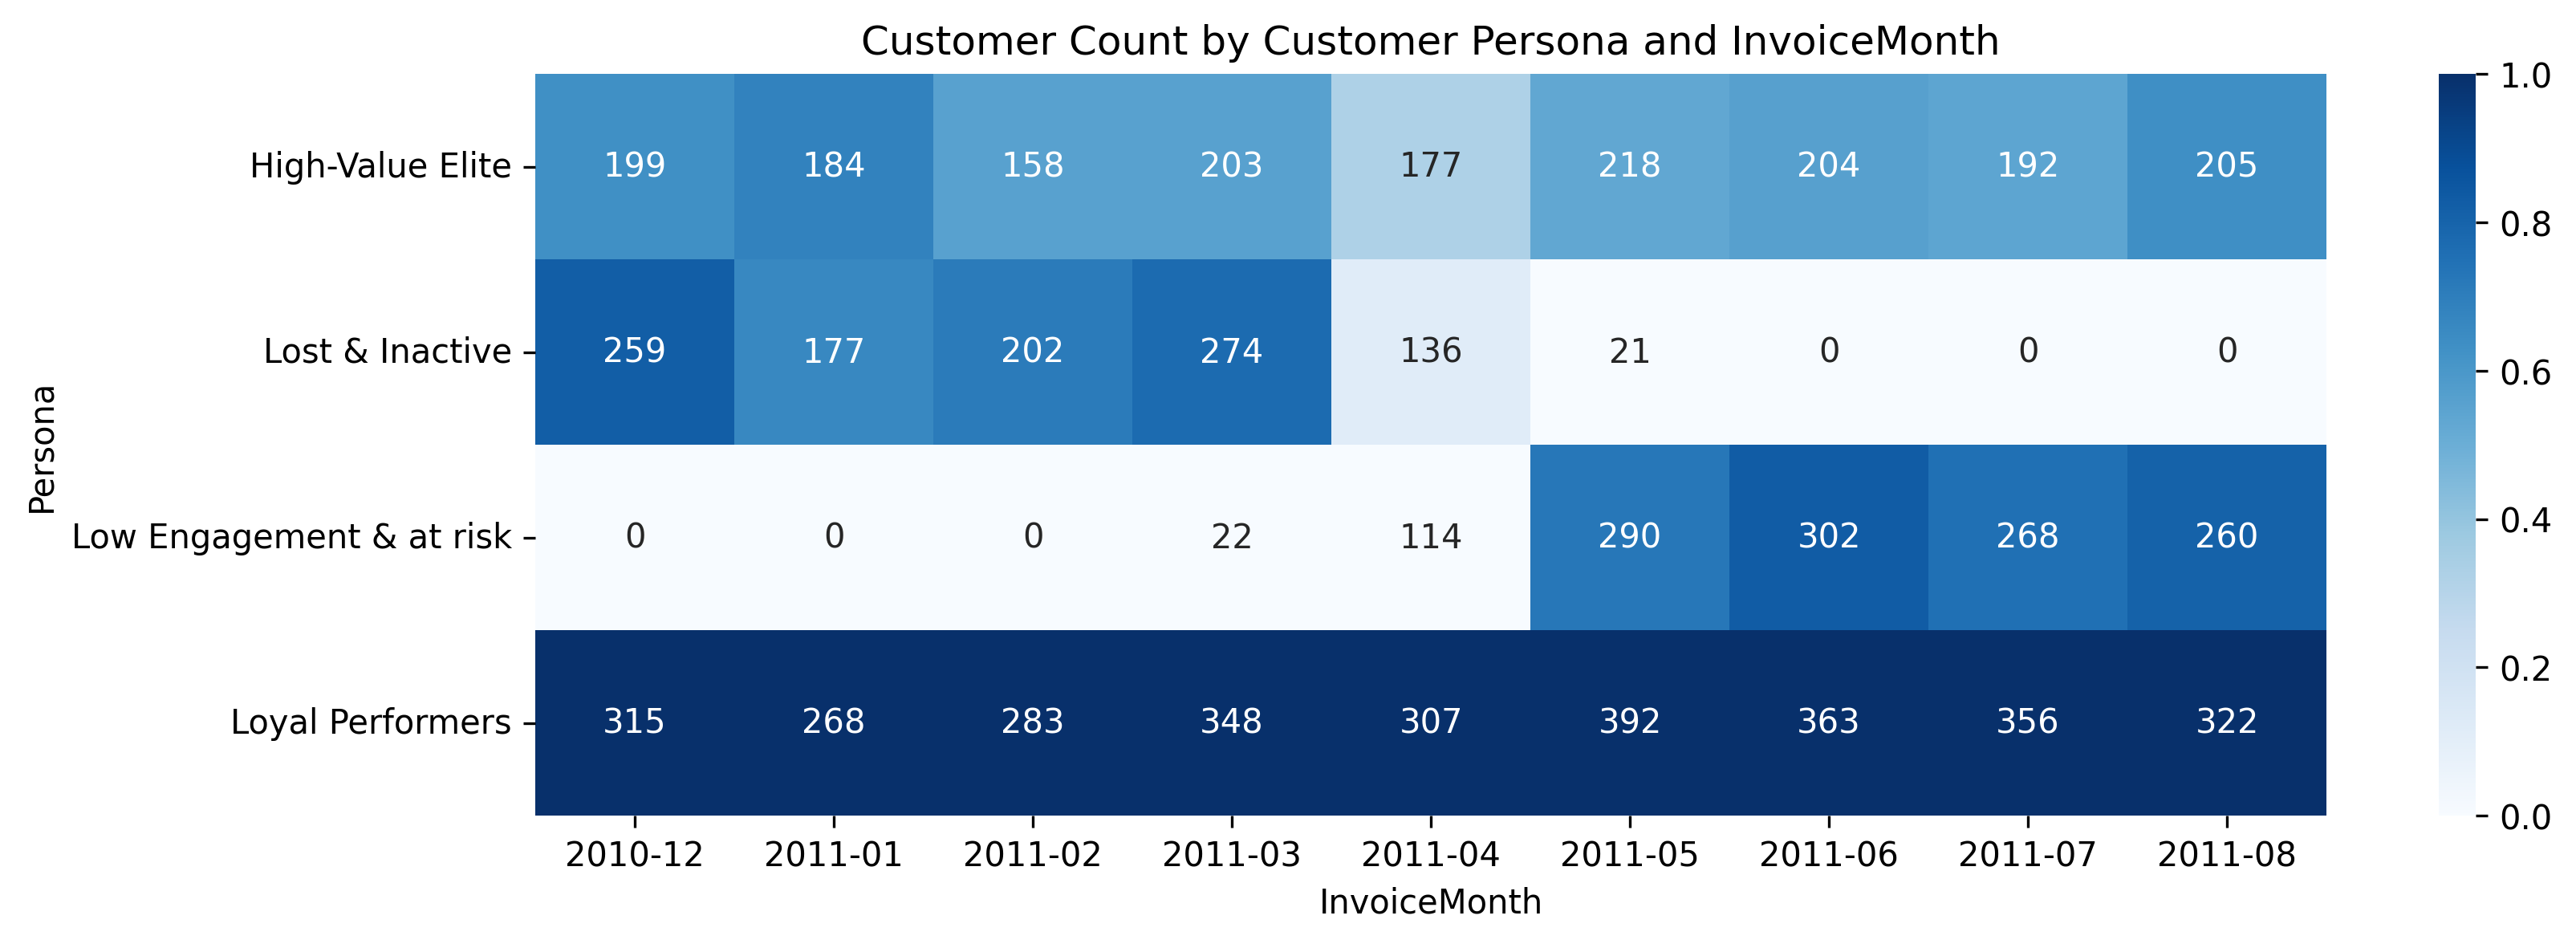

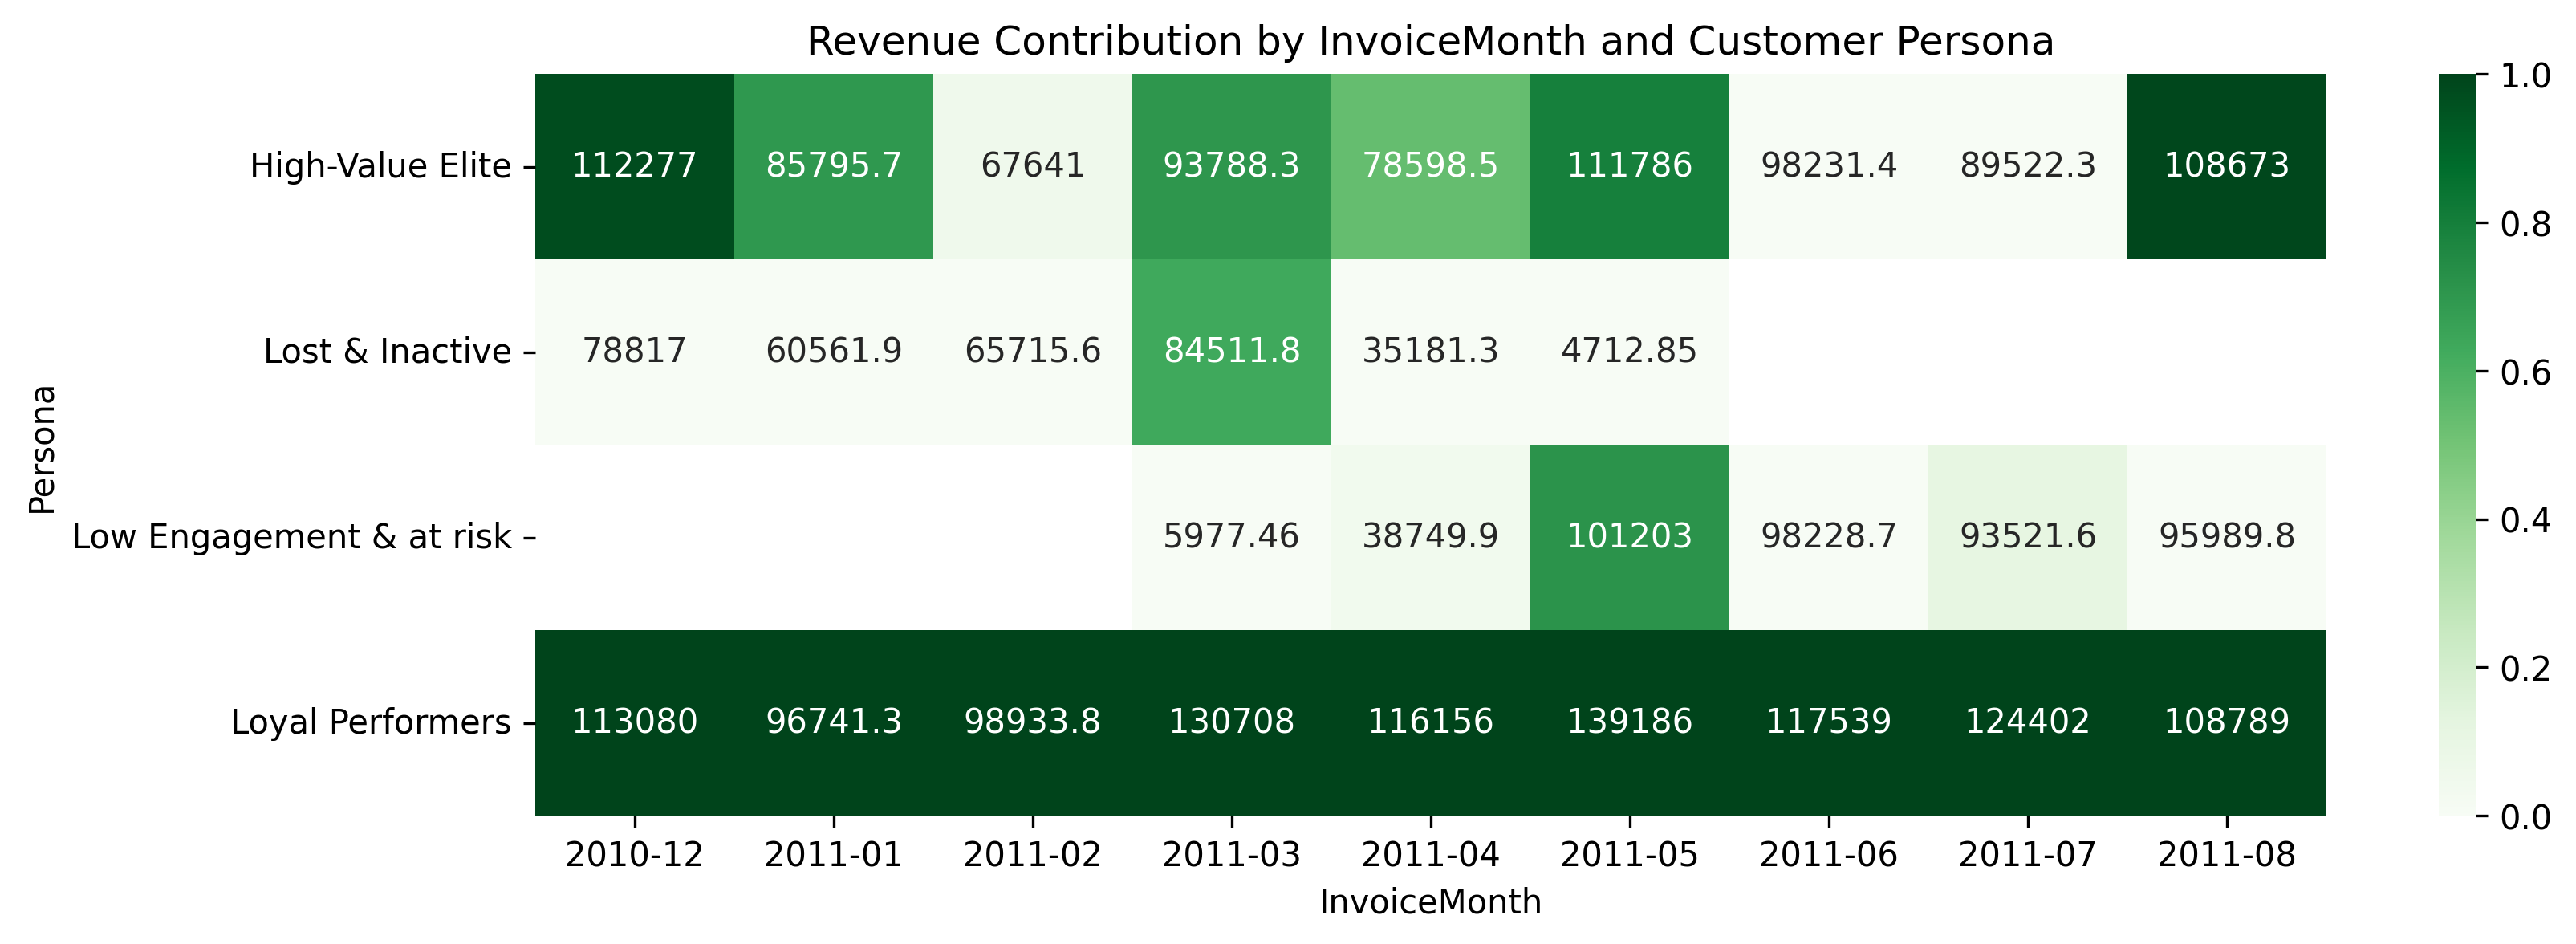

In [70]:
# Streaming dataset without date filters

parquet_url = "s3://sales-data-analytics-portfolio-2026/parquet_files/fact_online_retail_clean.parquet"
df_all = pd.read_parquet(parquet_url)

# Filtering dataset by date
cutoff_date = "2011-08-31"
filtered_df = df_all[df_all["InvoiceDate"].astype("str") <= cutoff_date]

data = filtered_df[["CustomerID","Revenue", "InvoiceDate"]].merge(df[["CustomerID", "Persona"]], how = "left", on = "CustomerID")

data["InvoiceMonth"] = data["InvoiceDate"].dt.to_period("M")

data1 = data.groupby(["CustomerID","Persona","InvoiceMonth"]).size().reset_index()
crosstab = pd.crosstab(data1["Persona"], data1["InvoiceMonth"])

crosstab_norm = (crosstab - crosstab.min())/(crosstab.max() - crosstab.min())

plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(data = crosstab_norm, annot = crosstab, cmap = "Blues", fmt = 'g')
plt.title("Customer Count by Customer Persona and InvoiceMonth")
plt.show()

summary = data.groupby(["Persona","InvoiceMonth"])["Revenue"].sum().reset_index()

summary1 = summary.pivot_table(index = "Persona", columns = "InvoiceMonth", values = "Revenue", aggfunc = "sum")

summary_norm = (summary1 - summary1.min())/(summary1.max() - summary1.min())

plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(data = summary_norm, annot = summary1, cmap = "Greens", fmt = 'g')
plt.title("Revenue Contribution by InvoiceMonth and Customer Persona")
plt.show()